# Bot-Predict — v4: entrada por PULLBACK (8 criptos, 4h, 3 años)

Notebook autocontenido: cada celda `%%writefile` escribe uno de los módulos del sistema directamente en el entorno de Colab (no hace falta subir ningún archivo `.py` a mano). Ejecuta las celdas en orden, de arriba a abajo.

**Cambio de esta versión**: tras 4 backtests reales convergiendo en Profit Factor ~1.00 (sin edge demostrado) con el cruce de EMA 20/50 como disparador de entrada, `modulo_2_estrategia.py` pasa a usar por defecto una entrada por **pullback** (el precio reclama la EMA rápida dentro de una tendencia ya intacta) en vez de esperar al cruce de dos EMAs — ver el docstring del módulo para el razonamiento completo. El cruce EMA-EMA se conserva como `disparador_entrada='cruce_ema'` (edita `CONFIG.disparador_entrada` para volver a él y comparar A/B sobre el mismo dato real).

La primera ejecución tarda bastante más de lo habitual: son 8 activos x 3 años de velas de 4h (~6570 velas por activo) descargadas de Kraken en varias peticiones paginadas por activo (ver `modulo_1_datos.py`). Ten paciencia con la celda 3.

Nota: XRP/USDT se probó y se retiró de la cesta — Kraken solo tiene ~4 meses de histórico real para ese par, no los 3 años pedidos (lo detectó `diagnosticar_activo()`, celda 6). Si algún otro activo de la cesta tiene el mismo problema, ahora la propia celda 3 lo avisa automáticamente en el log, sin falta de ejecutar la celda 6 a mano.

## 1. Instalar dependencias

In [ ]:
!pip install -q ccxt yfinance


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 849.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.3/133.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.5/219.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.0/134.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 4.7 MB/s eta 0:00:00


## 2. Escribir los módulos del sistema
Cada celda siguiente materializa uno de los módulos ya diseñados (arquitectura sin cambios: 4 módulos independientes + orquestador; el cambio de esta versión vive dentro de `modulo_2_estrategia.py`, no en la arquitectura).

In [ ]:
%%writefile modulo_1_datos.py
"""
=============================================================================
 BOT-PREDICT · MÓDULO 1: Configuración del entorno y extracción unificada
                          de datos (Acciones + Cripto)
=============================================================================

Objetivo del módulo
--------------------
Construir una única función de entrada que, sin importar si el activo es
una acción/ETF o una criptomoneda, siempre devuelva un DataFrame de pandas
con el MISMO esquema de columnas (Open, High, Low, Close, Volume + índice
de fecha en UTC).

¿Por qué es importante esto?
-----------------------------
Todo lo que construyamos después (indicadores técnicos, señales, motor de
riesgo, backtester) va a operar sobre ese DataFrame estandarizado. Si hoy
invertimos tiempo en una capa de datos limpia, evitamos que cada módulo
posterior tenga que "saber" si el dato viene de yfinance o de ccxt. Esto es
un principio de ingeniería de software (separación de responsabilidades /
"single source of truth" para el esquema de datos) tan importante como la
propia estrategia matemática: un backtest es tan fiable como los datos que
lo alimentan (regla de "garbage in, garbage out").

Fuentes de datos:
    - yfinance -> Acciones, ETFs, índices (Yahoo Finance).
    - ccxt     -> Criptomonedas, vía API pública de un exchange (Binance
                  por defecto, configurable).

Compatibilidad: pensado para correr igual en Google Colab que en local.
=============================================================================
"""

from __future__ import annotations

import logging
import time
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from enum import Enum
from typing import Optional

import pandas as pd

# -----------------------------------------------------------------------
# Dependencias externas. En Colab: !pip install yfinance ccxt -q
# En local: pip install yfinance ccxt
# -----------------------------------------------------------------------
try:
    import yfinance as yf
except ImportError as exc:  # pragma: no cover
    raise ImportError(
        "Falta 'yfinance'. Instálalo con: pip install yfinance"
    ) from exc

try:
    import ccxt
except ImportError as exc:  # pragma: no cover
    raise ImportError(
        "Falta 'ccxt'. Instálalo con: pip install ccxt"
    ) from exc


# -----------------------------------------------------------------------
# Configuración básica de logging.
# En un sistema de trading, tener trazabilidad de qué datos se pidieron,
# cuándo y con qué resultado no es opcional: es la base para poder
# depurar por qué una señal se disparó (o no) más adelante.
# -----------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger("bot_predict.datos")


class TipoActivo(str, Enum):
    """Distingue el origen del dato: acción/ETF vs criptomoneda.

    Usar un Enum en vez de strings sueltos ("stock", "crypto") evita
    errores de escritura (typos) y le da autocompletado a tu editor.
    """

    ACCION = "accion"
    CRIPTO = "cripto"


# Columnas que TODO DataFrame de salida de este módulo debe tener,
# en este orden exacto. Es el "contrato" que el resto del sistema
# puede asumir siempre válido.
ESQUEMA_OHLCV = ["Open", "High", "Low", "Close", "Volume"]


def _parsear_periodo_a_dias(periodo: str) -> int:
    """Convierte cadenas de periodo tipo '1y', '6mo', '90d' a días.

    Usa el mismo formato de cadena que ya acepta `yfinance` en su
    parámetro `period`, para que `ParametrosDescarga.periodo` sirva
    igual para acciones que para la paginación de cripto.
    """
    periodo_normalizado = periodo.strip().lower()
    if periodo_normalizado.endswith("mo"):
        return int(periodo_normalizado[:-2]) * 30
    if periodo_normalizado.endswith("y"):
        return int(periodo_normalizado[:-1]) * 365
    if periodo_normalizado.endswith("d"):
        return int(periodo_normalizado[:-1])
    raise ValueError(
        f"Formato de periodo no soportado: '{periodo}'. "
        "Usa 'Ny' (años), 'Nmo' (meses) o 'Nd' (días), p.ej. '1y', '6mo', '90d'."
    )


@dataclass
class ParametrosDescarga:
    """Agrupa los parámetros de una petición de datos.

    Usamos un dataclass en vez de pasar 5-6 argumentos sueltos a cada
    función: hace el código más legible y fácil de extender (por ejemplo,
    el día de mañana añadimos un campo `ajustado: bool` sin romper nada).
    """

    ticker: str
    tipo: TipoActivo
    intervalo: str = "1d"      # "1d" (diario) o "4h" (4 horas), etc.
    periodo: str = "2y"        # Horizonte histórico a descargar (yfinance)
    exchange_id: str = "binance"  # Exchange de ccxt para cripto


class ProveedorDatos:
    """Capa de datos unificada: acciones (yfinance) + cripto (ccxt).

    Esta clase es el único punto de entrada que el resto del sistema
    debería usar para obtener velas (OHLCV). Internamente decide si
    delega en yfinance o en ccxt según `TipoActivo`, pero de cara afuera
    siempre entrega el mismo formato.
    """

    def __init__(self, exchange_id: str = "binance") -> None:
        # Instanciamos el cliente del exchange una sola vez y lo
        # reutilizamos (evita overhead de crear conexiones repetidas).
        # enableRateLimit=True hace que ccxt espere automáticamente entre
        # peticiones lo necesario para no saturar la API pública del
        # exchange (importante en la paginación de _descargar_cripto).
        self._exchange_id = exchange_id
        self._exchange = getattr(ccxt, exchange_id)({"enableRateLimit": True})

    # ------------------------------------------------------------------
    # API pública
    # ------------------------------------------------------------------
    def obtener_datos(self, params: ParametrosDescarga) -> pd.DataFrame:
        """Punto de entrada único: enruta a la fuente correcta.

        Devuelve siempre un DataFrame con columnas ESQUEMA_OHLCV e
        índice de tipo datetime (UTC), ordenado cronológicamente.
        """
        logger.info(
            "Solicitando datos: %s (%s) intervalo=%s",
            params.ticker, params.tipo.value, params.intervalo,
        )

        if params.tipo is TipoActivo.ACCION:
            df = self._descargar_accion(params)
        elif params.tipo is TipoActivo.CRIPTO:
            df = self._descargar_cripto(params)
        else:  # Defensivo: si en el futuro se añade un TipoActivo nuevo
            raise ValueError(f"TipoActivo no soportado: {params.tipo}")

        return self._validar_y_normalizar(df, params.ticker)

    # ------------------------------------------------------------------
    # Fuente 1: Acciones / ETFs vía yfinance
    # ------------------------------------------------------------------
    def _descargar_accion(self, params: ParametrosDescarga) -> pd.DataFrame:
        df = yf.download(
            tickers=params.ticker,
            period=params.periodo,
            interval=params.intervalo,
            auto_adjust=True,   # Ajusta por dividendos/splits: precios comparables.
            progress=False,
        )

        if df.empty:
            raise ValueError(
                f"yfinance no devolvió datos para '{params.ticker}'. "
                "Revisa el ticker o el intervalo/periodo solicitado."
            )

        # yfinance a veces devuelve columnas en MultiIndex (p.ej. al pedir
        # varios tickers a la vez). Nos aseguramos de aplanarlo.
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        return df[ESQUEMA_OHLCV]

    # ------------------------------------------------------------------
    # Fuente 2: Criptomonedas vía ccxt (con paginación)
    # ------------------------------------------------------------------
    def _descargar_cripto(self, params: ParametrosDescarga) -> pd.DataFrame:
        # Los exchanges limitan cada petición de fetch_ohlcv a un número
        # máximo de velas (Binance ~1000, Kraken ~720, y varía según el
        # exchange). Para un histórico de 12 meses en 4h (~2190 velas)
        # hace falta más de una petición: paginamos avanzando el parámetro
        # `since` hasta cubrir todo el rango solicitado en `params.periodo`
        # (p.ej. "1y", "6mo", "90d"), sin asumir cuántas velas devuelve
        # cada llamada.
        timeframe = params.intervalo
        limite_por_peticion = 1000  # Techo solicitado; cada exchange aplica el suyo propio.

        dias_historial = _parsear_periodo_a_dias(params.periodo)
        desde_ms = int(
            (datetime.now(timezone.utc) - timedelta(days=dias_historial)).timestamp() * 1000
        )
        ahora_ms = int(datetime.now(timezone.utc).timestamp() * 1000)

        velas_acumuladas: list[list] = []
        cursor_ms = desde_ms
        max_iteraciones = 200  # cinturón y tirantes: nunca más de 200 peticiones.

        for _ in range(max_iteraciones):
            if cursor_ms >= ahora_ms:
                break

            try:
                lote = self._exchange.fetch_ohlcv(
                    symbol=params.ticker,
                    timeframe=timeframe,
                    since=cursor_ms,
                    limit=limite_por_peticion,
                )
            except Exception as exc:
                mensaje_error = str(exc)
                if "451" in mensaje_error or "403" in mensaje_error:
                    raise ConnectionError(
                        f"El exchange '{self._exchange_id}' ha rechazado la petición "
                        f"(código {'451' if '451' in mensaje_error else '403'}). Esto "
                        "suele significar un BLOQUEO GEOGRÁFICO: el servidor desde el "
                        "que ejecutas el script (p. ej. Google Colab, con IP de EE.UU.) "
                        "no tiene permitido el acceso a la API pública de este exchange. "
                        "Prueba con otro `exchange_id` en la configuración, p. ej. "
                        "'kraken' en vez de 'binance'."
                    ) from exc
                raise
            if not lote:
                break

            velas_acumuladas.extend(lote)
            ultimo_timestamp = lote[-1][0]

            # Protección anti bucle infinito: si el exchange no avanza el
            # cursor, cortamos en vez de quedarnos pidiendo lo mismo.
            if ultimo_timestamp <= cursor_ms:
                break
            cursor_ms = ultimo_timestamp + 1

            # OJO: NO usamos "len(lote) < limite_por_peticion" como señal de
            # "ya no hay más histórico". Es una suposición que rompe con
            # exchanges cuyo límite real por petición es menor que el
            # solicitado (p. ej. Kraken devuelve como mucho ~720 velas por
            # llamada, aunque pidamos 1000) -> cortaría la paginación tras
            # el primer lote y nos dejaría con muchos menos meses de los
            # pedidos, sin ningún error visible. La única señal fiable de
            # "ya no hay más" es haber alcanzado el presente (comprobado al
            # principio del bucle) o que el exchange devuelva un lote vacío.

            # Respeta el rate limit del exchange entre peticiones sucesivas.
            time.sleep(self._exchange.rateLimit / 1000)

        if not velas_acumuladas:
            raise ValueError(
                f"ccxt/{self._exchange_id} no devolvió datos para "
                f"'{params.ticker}'. Revisa el símbolo (formato BASE/QUOTE), "
                "el timeframe y el periodo solicitado."
            )

        df = pd.DataFrame(
            velas_acumuladas,
            columns=["timestamp", "Open", "High", "Low", "Close", "Volume"],
        )
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
        df.set_index("timestamp", inplace=True)

        logger.info(
            "%s: %d velas descargadas en paginación (~%d días de histórico).",
            params.ticker, len(df), dias_historial,
        )
        return df[ESQUEMA_OHLCV]

    # ------------------------------------------------------------------
    # Validación y normalización común a ambas fuentes
    # ------------------------------------------------------------------
    @staticmethod
    def _validar_y_normalizar(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
        """Aplica controles de calidad mínimos antes de entregar el dato.

        Esto es prevención temprana de sesgos: un dato corrupto o con
        huecos que pase desapercibido aquí puede generar señales falsas
        varios módulos más adelante, mucho más difíciles de detectar.
        """
        df = df.copy()

        # 1) Índice temporal ordenado y sin duplicados.
        df = df[~df.index.duplicated(keep="last")]
        df.sort_index(inplace=True)

        # 2) Tipos numéricos correctos (a veces llegan como object/str).
        for col in ESQUEMA_OHLCV:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # 3) Filas totalmente vacías o con precio <= 0 se descartan.
        filas_antes = len(df)
        df = df.dropna(subset=["Close"])
        df = df[df["Close"] > 0]
        filas_eliminadas = filas_antes - len(df)
        if filas_eliminadas > 0:
            logger.warning(
                "%s: se descartaron %d filas inválidas durante la limpieza.",
                ticker, filas_eliminadas,
            )

        if df.empty:
            raise ValueError(
                f"Tras la limpieza no quedaron datos válidos para '{ticker}'."
            )

        logger.info(
            "%s: %d velas listas (%s → %s).",
            ticker, len(df), df.index.min(), df.index.max(),
        )
        return df


# =============================================================================
# Bloque de auto-verificación (se ejecuta solo si corres este archivo
# directamente, no cuando lo importas como módulo desde otro script/notebook)
# =============================================================================
if __name__ == "__main__":
    proveedor = ProveedorDatos(exchange_id="binance")

    # --- Ejemplo 1: Acción (Apple, diario, últimos 2 años) ---
    datos_accion = proveedor.obtener_datos(
        ParametrosDescarga(ticker="AAPL", tipo=TipoActivo.ACCION,
                            intervalo="1d", periodo="2y")
    )
    print("\n=== AAPL (acción) ===")
    print(datos_accion.tail())

    # --- Ejemplo 2: Criptomoneda (Bitcoin, velas de 4h, últimos 12 meses) ---
    datos_cripto = proveedor.obtener_datos(
        ParametrosDescarga(ticker="BTC/USDT", tipo=TipoActivo.CRIPTO,
                            intervalo="4h", periodo="1y")
    )
    print("\n=== BTC/USDT (cripto) ===")
    print(datos_cripto.tail())


Writing modulo_1_datos.py


In [ ]:
%%writefile modulo_2_estrategia.py
"""
=============================================================================
 BOT-PREDICT · MÓDULO 2 (v4): Estrategia — entrada por PULLBACK en tendencia
             (sustituye al disparador de cruce de EMA de la v3) + ATR/RSI
             + filtro de régimen (EMA200 + ADX)
=============================================================================

Objetivo del módulo
--------------------
Convertir el DataFrame OHLCV estandarizado del Módulo 1 en una serie de
señales discretas mediante una única función parametrizada y VECTORIZADA
(sin bucles fila a fila en Python):

    1  -> Señal de compra / mantener largo
   -1  -> Señal de venta en corto (solo si permitir_cortos=True)
    0  -> Neutral / sin posición

Por qué esta versión existe: el veredicto de 4 backtests reales
-------------------------------------------------------------------
La v3 (cruce EMA 20/50 + filtro de régimen EMA200/ADX) se validó con 4
backtests reales independientes, de composición muy distinta (un activo
sin filtro, un activo con filtro, cesta de 5 activos, cesta de 8 activos;
12 meses y 3 años): en los tres casos con muestra informativa, el
resultado convergió sistemáticamente a Win Rate 35-38% y Profit Factor
alrededor de 1.00 (nunca claramente por encima) — ni ventaja real ni
pérdida catastrófica, un sistema que empata con el mercado antes de
comisiones. El diagnóstico de esa convergencia: los FILTROS DE RÉGIMEN
(EMA200 + ADX) no fueron señalados como la causa — se mantienen en esta
versión. El problema está en el DISPARADOR de entrada: el cruce de EMA
20/50 es, por construcción, una señal REZAGADA — dos medias que ya se
cruzaron implican que el movimiento que las cruzó ya ocurrió. En un
activo tan líquido y vigilado como BTC/USDT, es de las señales técnicas
más conocidas y más arbitradas que existen.

Qué cambia en la v4: entrada por PULLBACK, no por cruce
------------------------------------------------------------
En vez de esperar a que la EMA rápida cruce a la EMA lenta (evento lento,
doble suavizado), esta versión separa dos cosas que la v3 mezclaba en un
solo evento:

1. ESTRUCTURA de tendencia (estado, no evento): `ema_rapida > ema_lenta`
   para largos (`ema_rapida < ema_lenta` para cortos). Sustituye al
   "cruce" como confirmación de que la tendencia de corto/medio plazo
   sigue vigente, pero ahora se consulta como un ESTADO sostenido, no
   como el disparador en sí.
2. DISPARADOR de entrada (evento): un "reclamo" de la EMA rápida — el
   precio de cierre vuelve a superarla tras haber estado por debajo
   (`Close > ema_rapida` y `Close_prev <= ema_rapida_prev`), MIENTRAS la
   estructura de tendencia (1) sigue intacta. Esto es, en esencia,
   "comprar el retroceso dentro de una tendencia alcista ya establecida"
   en vez de "comprar en cuanto las dos medias se tocan" — se espera que
   entre más cerca del origen de la continuación del movimiento, no
   después de que ya se haya confirmado con el doble suavizado de la EMA
   lenta.

El antiguo cruce EMA-EMA no desaparece: pasa a ser la señal de SALIDA por
ruptura de estructura (si `ema_rapida` cruza a `ema_lenta` en contra de la
posición abierta, se cierra — la tendencia que sostenía la entrada ya no
existe). Los filtros de régimen (EMA200 + ADX) siguen aplicándose
ÚNICAMENTE a las entradas, exactamente igual que en la v3.

Para permitir una comparación A/B honesta contra la v3 (y no simplemente
asumir que el cambio es una mejora), se añade el parámetro
`disparador_entrada`: `"pullback"` (nuevo, por defecto) o `"cruce_ema"`
(comportamiento idéntico a la v3, conservado tal cual). Así, cualquier
resultado real de esta versión puede contrastarse contra la v3 sobre
EXACTAMENTE el mismo dato, cambiando un solo parámetro.

Limitación conocida, dicha sin rodeos
------------------------------------------
El "reclamo" de la EMA rápida es un evento más frecuente que el cruce de
dos EMAs (una sola media reacciona más rápido que dos), así que sin el
filtro de ADX podría generar más whipsaws en tramos donde el precio
oscila alrededor de la EMA rápida sin tendencia real. El filtro de ADX
existente debería filtrar la mayoría de esos casos, pero si un backtest
real muestra de nuevo muchas operaciones de baja calidad, el siguiente
paso razonable sería añadir un periodo de "enfriamiento" mínimo entre
reclamos consecutivos — no se implementa preventivamente aquí para no
añadir un parámetro más sin evidencia real que lo justifique.

Nota técnica: riesgo asimétrico largo vs. corto
--------------------------------------------------
Sin cambios respecto a la v3: el módulo sigue calculando una distancia de
stop-loss base asimétrica (ATR x2.0 en largo, ATR x1.5 en corto).
`permitir_cortos=False` por defecto, heredado de la prueba de estrés
post-auditoría 1.
=============================================================================
"""

from __future__ import annotations

import logging
from typing import Literal

import numpy as np
import pandas as pd

logger = logging.getLogger("bot_predict.estrategia")


# -----------------------------------------------------------------------
# Indicadores técnicos: pandas nativo (.ewm), sin dependencias externas.
# -----------------------------------------------------------------------

def calcular_ema(serie: pd.Series, periodo: int) -> pd.Series:
    """Media móvil exponencial (pondera más los precios recientes).

    `adjust=False` reproduce la fórmula recursiva clásica
    EMA_t = precio_t * alpha + EMA_{t-1} * (1 - alpha), la convención
    estándar en trading (en vez de la media ponderada exacta que usa
    pandas por defecto con adjust=True).
    """
    return serie.ewm(span=periodo, adjust=False).mean()


def _rango_verdadero(df: pd.DataFrame) -> pd.Series:
    """True Range de cada vela (incluye huecos frente al cierre anterior).

    Factorizado como helper independiente porque tanto `calcular_atr`
    como `calcular_adx` lo necesitan como paso intermedio — evita
    calcularlo dos veces con lógica duplicada.
    """
    high_low = df["High"] - df["Low"]
    high_cierre_prev = (df["High"] - df["Close"].shift(1)).abs()
    low_cierre_prev = (df["Low"] - df["Close"].shift(1)).abs()
    return pd.concat([high_low, high_cierre_prev, low_cierre_prev], axis=1).max(axis=1)


def calcular_atr(df: pd.DataFrame, periodo: int) -> pd.Series:
    """Average True Range: volatilidad absoluta reciente, incluyendo
    los huecos (gaps) entre el cierre anterior y la vela actual.
    """
    # Suavizado de Wilder: equivalente a una EMA con alpha = 1/periodo.
    return _rango_verdadero(df).ewm(alpha=1 / periodo, adjust=False).mean()


def calcular_rsi(serie: pd.Series, periodo: int) -> pd.Series:
    """Relative Strength Index (0-100): fuerza relativa de subidas vs.
    bajadas. >70 se interpreta como sobrecompra, <30 como sobreventa.
    """
    delta = serie.diff()
    ganancia = delta.clip(lower=0)
    perdida = -delta.clip(upper=0)

    media_ganancia = ganancia.ewm(alpha=1 / periodo, adjust=False).mean()
    media_perdida = perdida.ewm(alpha=1 / periodo, adjust=False).mean()

    fuerza_relativa = media_ganancia / media_perdida.replace(0, np.nan)
    rsi = 100 - (100 / (1 + fuerza_relativa))
    return rsi.fillna(100)  # Sin pérdidas en la ventana -> RSI = 100.


def calcular_adx(df: pd.DataFrame, periodo: int = 14) -> pd.Series:
    """Average Directional Index (0-100): fuerza de la tendencia, SIN
    indicar dirección (a diferencia de +DI/-DI, que sí son direccionales).

    Implementación clásica de Wilder, vectorizada con pandas/numpy:

    1. Movimiento direccional de cada vela:
       +DM = max(High_t - High_{t-1}, 0)  si supera al -DM, si no 0.
       -DM = max(Low_{t-1} - Low_t, 0)    si supera al +DM, si no 0.
    2. Se suavizan +DM, -DM y el True Range con el mismo suavizado de
       Wilder que ya usamos en ATR/RSI (alpha = 1/periodo).
    3. +DI = 100 * (+DM suavizado / TR suavizado); -DI análogo.
    4. DX = 100 * |+DI - -DI| / (+DI + -DI)  (asimetría direccional, 0-100).
    5. ADX = suavizado de Wilder de DX.

    Al ser un indicador con DOS suavizados encadenados (DM/TR, y luego
    DX->ADX), su fase de calentamiento es más larga que la de un
    indicador de un solo suavizado como el RSI — ver el enmascarado
    explícito de NaN en `generar_senales`.
    """
    subida_high = df["High"].diff()
    bajada_low = -df["Low"].diff()  # Low_{t-1} - Low_t, positivo si el mínimo baja.

    dm_mas = np.where((subida_high > bajada_low) & (subida_high > 0), subida_high, 0.0)
    dm_menos = np.where((bajada_low > subida_high) & (bajada_low > 0), bajada_low, 0.0)

    tr_suavizado = _rango_verdadero(df).ewm(alpha=1 / periodo, adjust=False).mean()
    dm_mas_suavizado = pd.Series(dm_mas, index=df.index).ewm(alpha=1 / periodo, adjust=False).mean()
    dm_menos_suavizado = pd.Series(dm_menos, index=df.index).ewm(alpha=1 / periodo, adjust=False).mean()

    di_mas = 100 * (dm_mas_suavizado / tr_suavizado.replace(0, np.nan))
    di_menos = 100 * (dm_menos_suavizado / tr_suavizado.replace(0, np.nan))

    suma_di = (di_mas + di_menos).replace(0, np.nan)
    dx = 100 * (di_mas - di_menos).abs() / suma_di
    dx = dx.fillna(0)  # Sin movimiento direccional neto -> DX = 0 (no NaN).

    adx = dx.ewm(alpha=1 / periodo, adjust=False).mean()
    return adx


def calcular_distancia_stop_atr(
    atr: pd.Series,
    direccion: pd.Series,
    atr_mult_largo: float = 2.0,
    atr_mult_corto: float = 1.5,
) -> pd.Series:
    """Lógica BASE del stop-loss asimétrico (se completa en el Módulo 3).

    Devuelve, para cada vela, la DISTANCIA en unidades de precio entre el
    precio de entrada y el stop-loss, según la dirección de la posición:
        - Largo -> atr * atr_mult_largo   (p.ej. 2.0x ATR)
        - Corto -> atr * atr_mult_corto   (p.ej. 1.5x ATR, más ceñido)
    """
    multiplicador = np.select(
        [direccion == 1, direccion == -1],
        [atr_mult_largo, atr_mult_corto],
        default=np.nan,
    )
    return atr * multiplicador


# -----------------------------------------------------------------------
# Generador de señales: función única, parametrizada y vectorizada.
# -----------------------------------------------------------------------

def generar_senales(
    df: pd.DataFrame,
    ema_rapida: int = 20,
    ema_lenta: int = 50,
    periodo_atr: int = 14,
    periodo_rsi: int = 14,
    rsi_sobrecompra: float = 70.0,
    rsi_sobreventa: float = 30.0,
    rsi_agotamiento_largo: float = 80.0,
    rsi_agotamiento_corto: float = 20.0,
    atr_pct_minimo: float = 0.0,
    permitir_cortos: bool = False,
    atr_mult_stop_largo: float = 2.0,
    atr_mult_stop_corto: float = 1.5,
    usar_filtro_macro: bool = True,
    periodo_ema_macro: int = 200,
    usar_adx: bool = True,
    periodo_adx: int = 14,
    umbral_adx: float = 22.0,
    disparador_entrada: Literal["pullback", "cruce_ema"] = "pullback",
) -> pd.DataFrame:
    """Genera indicadores y señales de trading, con filtro de régimen.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas ``Open, High, Low, Close, Volume`` (esquema
        estandarizado del Módulo 1) e índice temporal ordenado.
    ema_rapida, ema_lenta : int
        Periodos de las EMA que definen la estructura de tendencia. 20/50
        por defecto (ver docstring del módulo). Con
        `disparador_entrada="pullback"` actúan como un ESTADO (¿sigue la
        tendencia intacta?), no como el evento que dispara la entrada.
    periodo_atr, periodo_rsi : int
        Ventanas de cálculo del ATR y el RSI.
    rsi_sobrecompra, rsi_sobreventa : float
        Umbrales que BLOQUEAN una nueva entrada por sobrecompra/sobreventa.
    rsi_agotamiento_largo, rsi_agotamiento_corto : float
        Umbrales que FUERZAN el cierre de una posición abierta.
    atr_pct_minimo : float
        ATR mínimo (como fracción del precio) para permitir operar.
    permitir_cortos : bool
        Si True, genera también señales en corto (-1). **Por defecto
        False** en esta versión: la prueba de estrés post-auditoría aísla
        la rentabilidad del lado comprador, dado que los cortos
        concentraron la mayoría de las pérdidas en la v2.
    atr_mult_stop_largo, atr_mult_stop_corto : float
        Multiplicadores de ATR para la distancia de stop-loss base.
    usar_filtro_macro : bool
        Activa el filtro de tendencia macro (régimen nº 1). Si False, se
        ignora `periodo_ema_macro` por completo (útil para comparar
        con/sin filtro sin recurrir a valores de periodo artificiales).
    periodo_ema_macro : int
        Periodo de la EMA de tendencia de fondo (filtro de régimen nº 1).
        Una entrada larga solo es válida con Close > EMA_macro; una corta,
        solo con Close < EMA_macro. 200 por defecto.
    usar_adx : bool
        Activa el filtro de fuerza direccional (régimen nº 2). Si False,
        se ignora el ADX por completo (útil para comparar con/sin filtro).
    periodo_adx : int
        Ventana de cálculo del ADX (suavizado de Wilder doble).
    umbral_adx : float
        ADX mínimo para aceptar una entrada. Por debajo de este umbral se
        interpreta que el mercado no tiene una tendencia lo bastante
        definida como para operar con confianza.
    disparador_entrada : "pullback" | "cruce_ema"
        Mecanismo que dispara la entrada (ver docstring del módulo para el
        razonamiento completo):
        - "pullback" (v4, por defecto): entra cuando el precio "reclama"
          la EMA rápida (cierre vuelve a superarla tras haber estado
          debajo) MIENTRAS la estructura `ema_rapida`/`ema_lenta` sigue
          alineada con la tendencia. El cruce EMA-EMA pasa a ser señal de
          SALIDA por ruptura de estructura, no de entrada.
        - "cruce_ema" (v3, conservado para comparación A/B): comportamiento
          idéntico a la versión anterior — entra en el instante exacto en
          que `ema_rapida` cruza a `ema_lenta`.
        En ambos casos los filtros de régimen (macro + ADX) y de calidad
        (RSI + volatilidad) se aplican igual, solo a las entradas.

    Returns
    -------
    pd.DataFrame
        Copia de `df` con las columnas de indicadores añadidas (incluye
        `ema_macro` y, si `usar_adx=True`, `adx`) y una columna final
        `senal` (1 / -1 / 0).
    """
    df = df.copy()

    # 1) Indicadores base (idénticos a la v2).
    df["ema_rapida"] = calcular_ema(df["Close"], ema_rapida)
    df["ema_lenta"] = calcular_ema(df["Close"], ema_lenta)
    df["atr"] = calcular_atr(df, periodo_atr)
    df["atr_pct"] = df["atr"] / df["Close"]
    df["rsi"] = calcular_rsi(df["Close"], periodo_rsi)

    # 1b) Indicadores de RÉGIMEN (nuevos en esta versión).
    if usar_filtro_macro:
        df["ema_macro"] = calcular_ema(df["Close"], periodo_ema_macro)
        # Enmascarado EXPLÍCITO del periodo de calentamiento: aunque
        # `.ewm()` produce un valor desde la primera vela (no NaN "de
        # fábrica"), una EMA de 200 periodos calculada sobre menos de 200
        # velas no es estadísticamente lo que dice ser -> la anulamos a
        # propósito durante las primeras `periodo_ema_macro` velas, para
        # que el filtro de tendencia macro NUNCA autorice una entrada con
        # datos insuficientes (una comparación contra NaN se evalúa como
        # False, así que estas velas quedan automáticamente excluidas).
        df.loc[df.index[:periodo_ema_macro], "ema_macro"] = np.nan

    if usar_adx:
        df["adx"] = calcular_adx(df, periodo_adx)
        # El ADX encadena dos suavizados de Wilder (DM/TR, y DX->ADX): su
        # calentamiento fiable requiere más velas que un solo suavizado.
        # Enmascaramos el doble del periodo, mismo criterio explícito que
        # con la EMA macro.
        velas_calentamiento_adx = periodo_adx * 2
        df.loc[df.index[:velas_calentamiento_adx], "adx"] = np.nan
        filtro_adx = df["adx"] >= umbral_adx
    else:
        filtro_adx = pd.Series(True, index=df.index)

    # 2) Estructura de tendencia (estado sostenido) + eventos de cruce
    #    EMA-EMA. En "pullback" (v4), la estructura filtra la entrada y el
    #    cruce se usa como salida por ruptura; en "cruce_ema" (v3), el
    #    cruce se usa directamente como disparador de entrada.
    estructura_alcista = df["ema_rapida"] > df["ema_lenta"]
    estructura_bajista = df["ema_rapida"] < df["ema_lenta"]
    cruce_alcista = estructura_alcista & (
        df["ema_rapida"].shift(1) <= df["ema_lenta"].shift(1)
    )
    cruce_bajista = estructura_bajista & (
        df["ema_rapida"].shift(1) >= df["ema_lenta"].shift(1)
    )

    # 2b) Evento de "reclamo" de la EMA rápida (disparador de la v4): el
    #     cierre vuelve a superarla (o a perderla, para cortos) tras haber
    #     estado al otro lado en la vela anterior — la firma de un
    #     retroceso ("pullback") que se resuelve a favor de la tendencia.
    reclamo_alcista = (df["Close"] > df["ema_rapida"]) & (
        df["Close"].shift(1) <= df["ema_rapida"].shift(1)
    )
    reclamo_bajista = (df["Close"] < df["ema_rapida"]) & (
        df["Close"].shift(1) >= df["ema_rapida"].shift(1)
    )

    if disparador_entrada == "pullback":
        evento_entrada_largo = reclamo_alcista & estructura_alcista
        evento_entrada_corto = reclamo_bajista & estructura_bajista
    elif disparador_entrada == "cruce_ema":
        evento_entrada_largo = cruce_alcista
        evento_entrada_corto = cruce_bajista
    else:
        raise ValueError(
            f"disparador_entrada debe ser 'pullback' o 'cruce_ema', recibido: "
            f"'{disparador_entrada}'."
        )

    # 3) Filtros de calidad sobre las entradas (RSI + volatilidad, v2).
    filtro_volatilidad = df["atr_pct"] >= atr_pct_minimo
    filtro_rsi_largo = df["rsi"] < rsi_sobrecompra
    filtro_rsi_corto = df["rsi"] > rsi_sobreventa

    # 3b) Filtros de RÉGIMEN: tendencia macro + fuerza direccional.
    # Comparaciones con NaN (periodo de calentamiento) se evalúan como
    # False en pandas -> no autorizan entrada, sin necesidad de lógica
    # adicional.
    if usar_filtro_macro:
        filtro_tendencia_macro_largo = df["Close"] > df["ema_macro"]
        filtro_tendencia_macro_corto = df["Close"] < df["ema_macro"]
    else:
        filtro_tendencia_macro_largo = pd.Series(True, index=df.index)
        filtro_tendencia_macro_corto = pd.Series(True, index=df.index)

    entrada_larga = (
        evento_entrada_largo
        & filtro_rsi_largo
        & filtro_volatilidad
        & filtro_tendencia_macro_largo
        & filtro_adx
    )
    entrada_corta = (
        permitir_cortos
        & evento_entrada_corto
        & filtro_rsi_corto
        & filtro_volatilidad
        & filtro_tendencia_macro_corto
        & filtro_adx
    )

    # 4) Eventos de salida forzada. La ruptura de ESTRUCTURA (cruce EMA-EMA
    #    en contra de la posición) cierra siempre, sea cual sea el
    #    disparador de entrada usado — si la tendencia que sostenía la
    #    entrada ya no existe, la razón para seguir dentro tampoco.
    #    El agotamiento por RSI es idéntico a la v3: el filtro de régimen
    #    aplica solo a la decisión de ENTRAR, nunca a la de salir -> una
    #    vez dentro, la gestión de riesgo manda.
    salida_larga_rsi = (df["rsi"] > rsi_agotamiento_largo) & (
        df["rsi"].shift(1) <= rsi_agotamiento_largo
    )
    salida_corta_rsi = (df["rsi"] < rsi_agotamiento_corto) & (
        df["rsi"].shift(1) >= rsi_agotamiento_corto
    )

    # 5) Ensamblado vectorizado de la señal como estado sostenido (ffill
    #    de eventos), igual que en versiones anteriores.
    senal_bruta = pd.Series(np.nan, index=df.index)
    senal_bruta.loc[salida_larga_rsi] = 0
    senal_bruta.loc[salida_corta_rsi] = 0
    senal_bruta.loc[cruce_bajista & ~permitir_cortos] = 0  # sin cortos: solo cerrar largo
    senal_bruta.loc[entrada_larga] = 1
    senal_bruta.loc[entrada_corta] = -1

    df["senal"] = senal_bruta.ffill().fillna(0).astype(int)

    # 6) Distancia de stop-loss base (asimétrica), previsualización del
    #    Módulo 3.
    df["distancia_stop_atr"] = calcular_distancia_stop_atr(
        df["atr"], df["senal"], atr_mult_stop_largo, atr_mult_stop_corto
    )

    logger.info(
        "Señales generadas (con filtro de régimen): %d velas largas, "
        "%d cortas, %d planas.",
        (df["senal"] == 1).sum(),
        (df["senal"] == -1).sum(),
        (df["senal"] == 0).sum(),
    )
    return df


# =============================================================================
# Bloque de auto-verificación: datos simulados (tendencia + tramo lateral)
# para comprobar que el filtro de régimen realmente reduce las señales en
# la parte sin tendencia, sin depender de red ni de las APIs del Módulo 1.
# =============================================================================
if __name__ == "__main__":
    rng = np.random.default_rng(42)
    n = 900
    indice = pd.date_range("2023-01-01", periods=n, freq="4h", tz="UTC")

    # Primer tercio: tendencia alcista clara. Segundo tercio: lateral puro
    # (ruido sin deriva). Tercer tercio: tendencia alcista de nuevo.
    tramo_tendencia_1 = np.linspace(0, 30, n // 3)
    tramo_lateral = np.zeros(n // 3)
    tramo_tendencia_2 = np.linspace(0, 25, n - 2 * (n // 3))
    deriva = np.concatenate([tramo_tendencia_1, tramo_lateral, tramo_tendencia_2])
    precio_base = 100 + np.cumsum(rng.normal(0, 1, n)) * 0.4 + deriva

    df_simulado = pd.DataFrame(
        {
            "Open": precio_base,
            "High": precio_base + rng.random(n) * 2,
            "Low": precio_base - rng.random(n) * 2,
            "Close": precio_base + rng.normal(0, 0.5, n),
            "Volume": rng.integers(100, 1000, n),
        },
        index=indice,
    )

    print(">>> SIN filtro de régimen (equivalente a la v2, solo largos):")
    resultado_sin_filtro = generar_senales(
        df_simulado, permitir_cortos=False, usar_adx=False, usar_filtro_macro=False,
    )
    n_entradas_sin_filtro = (
        (resultado_sin_filtro["senal"].diff() != 0) & (resultado_sin_filtro["senal"] == 1)
    ).sum()
    print(f"Entradas largas detectadas: {n_entradas_sin_filtro}")

    print("\n>>> CON filtro de régimen (EMA200 + ADX>=22), disparador CRUCE_EMA (v3):")
    resultado_cruce = generar_senales(
        df_simulado, permitir_cortos=False, disparador_entrada="cruce_ema",
    )
    n_entradas_cruce = (
        (resultado_cruce["senal"].diff() != 0) & (resultado_cruce["senal"] == 1)
    ).sum()
    print(f"Entradas largas detectadas: {n_entradas_cruce}")

    print("\n>>> CON filtro de régimen (EMA200 + ADX>=22), disparador PULLBACK (v4, nuevo):")
    resultado_pullback = generar_senales(
        df_simulado, permitir_cortos=False, disparador_entrada="pullback",
    )
    n_entradas_pullback = (
        (resultado_pullback["senal"].diff() != 0) & (resultado_pullback["senal"] == 1)
    ).sum()
    print(f"Entradas largas detectadas: {n_entradas_pullback}")
    print(
        "(Se espera más entradas que con 'cruce_ema': el reclamo de la EMA "
        "rápida es un evento más frecuente que el cruce de dos EMAs — el "
        "filtro de régimen es el que debe mantener la calidad, no la "
        "escasez del disparador.)"
    )

    columnas_a_mostrar = ["Close", "ema_macro", "adx", "senal"]
    print("\nÚltimas filas con el disparador 'pullback' activo:")
    print(resultado_pullback[columnas_a_mostrar].tail(10).to_string())


Writing modulo_2_estrategia.py


In [ ]:
%%writefile modulo_3_riesgo.py
"""
=============================================================================
 BOT-PREDICT · MÓDULO 3: Dimensionamiento de posición y gestión de riesgo
=============================================================================

Objetivo del módulo
--------------------
Convertir una señal de entrada (precio, dirección, ATR del momento) en un
plan de operación completo y cuantificado: precio de stop-loss, precio de
take-profit, y el TAMAÑO de la posición — la pieza que, en la práctica,
protege más el capital que la propia señal de entrada.

Position sizing por riesgo fijo vs. tamaño de lote constante
----------------------------------------------------------------
El error más común de un trader novato es operar con un tamaño FIJO de
posición (p. ej. "siempre compro 100 acciones" o "siempre 0.1 BTC"),
independientemente de dónde esté el stop-loss. Esto hace que el riesgo
monetario real varíe sin control operación a operación: si el stop está
cerca, arriesgas poco; si está lejos (activo más volátil, stop más ancho),
arriesgas mucho más sin haberlo decidido conscientemente.

El "position sizing por riesgo fijo" invierte el problema: en vez de fijar
el tamaño y dejar que el riesgo flote, fijamos el RIESGO (un % constante
del capital, la regla del 1-2%) y dejamos que el TAMAÑO se ajuste:

                        Capital × Riesgo%
    Tamaño (unidades) = ------------------
                        Distancia al Stop

Así, tanto si el stop está a $500 como a $2.000 de la entrada, la pérdida
máxima en caso de que salte el stop es siempre la misma cantidad de dinero
(en términos relativos al capital). Es la diferencia entre "decidir cuánto
puedo perder" y "descubrir cuánto perdiste después de perderlo".

Por qué el ATR es superior a un stop de % fijo
----------------------------------------------
Un stop de porcentaje fijo (p. ej. "siempre -3%") ignora que no todos los
activos ni todos los momentos de mercado tienen la misma volatilidad. Un
-3% en un activo de baja volatilidad puede ser un stop absurdamente ancho
(nunca te saca aunque la tesis haya fallado); ese mismo -3% en un activo
muy volátil puede saltar por simple ruido normal de mercado, sin que la
tendencia se haya invalidado realmente. El ATR resuelve esto porque mide
la volatilidad REAL y RECIENTE de ESE activo en ESE momento: el stop se
adapta activo a activo y periodo a periodo, en vez de aplicar la misma
regla arbitraria a todo. Es el mismo principio que ya usamos en el
Módulo 2 para diferenciar el stop de largos y cortos, llevado ahora al
dimensionamiento de la posición completa.
=============================================================================
"""

from __future__ import annotations

import logging
import math
from dataclasses import dataclass, field

logger = logging.getLogger("bot_predict.riesgo")

_EPSILON = 1e-8  # Umbral por debajo del cual consideramos una distancia "cero".


@dataclass
class ResultadoGestionRiesgo:
    """Plan de operación completo devuelto por `calcular_gestion_riesgo`.

    Reunir todos los resultados en un único objeto (en vez de devolver una
    tupla suelta de 6 valores) hace el código que lo consume más legible
    (`plan.precio_stop_loss` en vez de recordar que es el segundo elemento
    de una tupla) y más fácil de extender sin romper firmas de función.
    """

    direccion: int
    precio_entrada: float
    distancia_stop: float
    precio_stop_loss: float
    precio_take_profit: float
    distancia_take_profit: float
    tamano_posicion: float
    capital_arriesgado: float
    capital_invertido: float
    perdida_maxima_teorica: float
    advertencias: list[str] = field(default_factory=list)


def calcular_gestion_riesgo(
    precio_entrada: float,
    atr: float,
    direccion: int,
    capital_cuenta: float = 10_000.0,
    riesgo_por_operacion: float = 0.01,
    atr_mult_stop_largo: float = 2.0,
    atr_mult_stop_corto: float = 1.5,
    ratio_riesgo_beneficio: float = 2.0,
    decimales_unidades: int = 6,
    unidades_fraccionables: bool = True,
    permitir_apalancamiento: bool = False,
) -> ResultadoGestionRiesgo:
    """Calcula stop-loss, take-profit y tamaño de posición para una señal.

    Parameters
    ----------
    precio_entrada : float
        Precio al que se abriría la posición.
    atr : float
        Average True Range vigente en el momento de la entrada (mismo
        ATR calculado en el Módulo 2).
    direccion : int
        1 = posición larga, -1 = posición corta.
    capital_cuenta : float
        Capital total disponible en la cuenta. Argumento configurable por
        llamada (nunca hardcoded), para poder simular distintos tamaños de
        cuenta en el backtest del Módulo 4.
    riesgo_por_operacion : float
        Fracción del capital que se está dispuesto a perder si el stop-loss
        salta (regla del 1-2%: 0.01 = 1%, 0.02 = 2%). También configurable
        por llamada.
    atr_mult_stop_largo, atr_mult_stop_corto : float
        Multiplicadores de ATR para la distancia del stop, asimétricos por
        el riesgo direccional distinto entre largos y cortos (ver Módulo 2).
    ratio_riesgo_beneficio : float
        Múltiplo de la distancia del stop que define la distancia del
        take-profit. Por defecto 2.0 -> ratio R:R de 1:2.
    decimales_unidades : int
        Precisión de redondeo del tamaño de posición cuando
        `unidades_fraccionables=True` (p. ej. cripto, 6 decimales típico).
    unidades_fraccionables : bool
        True (por defecto) para activos que admiten fracciones (cripto).
        False para redondear HACIA ABAJO a unidades enteras (acciones al
        contado, donde no existen fracciones de acción en la mayoría de
        brokers) — se redondea siempre hacia abajo, nunca hacia arriba,
        para no superar el riesgo objetivo.
    permitir_apalancamiento : bool
        Si False (por defecto), el tamaño de posición se limita para que
        el capital invertido (tamaño × precio) nunca supere el capital de
        la cuenta -> comportamiento "spot", sin apalancamiento. Si esto
        recorta el tamaño calculado por riesgo, se añade una advertencia:
        significa que el stop está tan cerca del precio que el sizing por
        riesgo puro pediría más exposición de la que el capital permite.

    Returns
    -------
    ResultadoGestionRiesgo
        Objeto con el plan de operación completo. Revisa siempre el campo
        `advertencias` antes de operar con el resultado.
    """
    if direccion not in (1, -1):
        raise ValueError("direccion debe ser 1 (largo) o -1 (corto).")
    if precio_entrada <= 0:
        raise ValueError("precio_entrada debe ser positivo.")
    if not 0 < riesgo_por_operacion < 1:
        raise ValueError("riesgo_por_operacion debe estar entre 0 y 1 (p. ej. 0.01).")

    advertencias: list[str] = []

    # 1) Distancia del stop, con el multiplicador asimétrico según dirección.
    multiplicador_stop = atr_mult_stop_largo if direccion == 1 else atr_mult_stop_corto
    distancia_stop = atr * multiplicador_stop

    # 2) Guarda defensiva: ATR nulo/insignificante -> no se puede dimensionar
    #    con seguridad (dividir por ~0 dispararía un tamaño de posición
    #    absurdamente grande). En vez de lanzar una excepción que tumbe un
    #    backtest completo, devolvemos un plan con tamaño 0 y lo advertimos.
    if distancia_stop < _EPSILON:
        logger.warning(
            "ATR/distancia de stop insignificante (%.10f) para precio_entrada=%.4f; "
            "no se puede dimensionar la posición de forma segura.",
            distancia_stop, precio_entrada,
        )
        return ResultadoGestionRiesgo(
            direccion=direccion,
            precio_entrada=precio_entrada,
            distancia_stop=distancia_stop,
            precio_stop_loss=precio_entrada,
            precio_take_profit=precio_entrada,
            distancia_take_profit=0.0,
            tamano_posicion=0.0,
            capital_arriesgado=0.0,
            capital_invertido=0.0,
            perdida_maxima_teorica=0.0,
            advertencias=["ATR/distancia de stop insignificante: posición descartada (tamaño 0)."],
        )

    # 3) Precios de stop-loss y take-profit según dirección.
    distancia_take_profit = distancia_stop * ratio_riesgo_beneficio
    if direccion == 1:  # Largo: stop debajo, take-profit encima.
        precio_stop_loss = precio_entrada - distancia_stop
        precio_take_profit = precio_entrada + distancia_take_profit
    else:  # Corto: stop encima, take-profit debajo.
        precio_stop_loss = precio_entrada + distancia_stop
        precio_take_profit = precio_entrada - distancia_take_profit

    # 4) Dimensionamiento por riesgo fijo: la fórmula central del módulo.
    capital_arriesgado = capital_cuenta * riesgo_por_operacion
    tamano_posicion = capital_arriesgado / distancia_stop

    # 5) Redondeo a unidades operativas válidas.
    if unidades_fraccionables:
        tamano_posicion = round(tamano_posicion, decimales_unidades)
    else:
        # floor (no round) para no superar nunca el riesgo objetivo.
        tamano_posicion = math.floor(tamano_posicion)

    # 6) Control de límites: sin apalancamiento, el nocional invertido no
    #    puede superar el capital disponible (comportamiento "spot").
    capital_invertido = tamano_posicion * precio_entrada
    if not permitir_apalancamiento and capital_invertido > capital_cuenta:
        tamano_maximo_por_capital = capital_cuenta / precio_entrada
        tamano_posicion = (
            round(tamano_maximo_por_capital, decimales_unidades)
            if unidades_fraccionables
            else math.floor(tamano_maximo_por_capital)
        )
        capital_invertido = tamano_posicion * precio_entrada
        advertencias.append(
            "El tamaño de posición por riesgo puro superaba el capital disponible "
            "(implicaría apalancamiento); se ha recortado al máximo sin apalancar. "
            "La pérdida máxima real es ahora menor que el riesgo objetivo."
        )

    # 7) Pérdida máxima teórica real (puede ser menor que capital_arriesgado
    #    si el paso 6 recortó el tamaño).
    perdida_maxima_teorica = tamano_posicion * distancia_stop

    if tamano_posicion <= 0:
        advertencias.append(
            "El tamaño de posición resultante es 0 (redondeo a unidades enteras "
            "o capital insuficiente para el precio de entrada dado)."
        )

    return ResultadoGestionRiesgo(
        direccion=direccion,
        precio_entrada=precio_entrada,
        distancia_stop=distancia_stop,
        precio_stop_loss=precio_stop_loss,
        precio_take_profit=precio_take_profit,
        distancia_take_profit=distancia_take_profit,
        tamano_posicion=tamano_posicion,
        capital_arriesgado=capital_arriesgado,
        capital_invertido=capital_invertido,
        perdida_maxima_teorica=perdida_maxima_teorica,
        advertencias=advertencias,
    )


def _imprimir_plan(etiqueta: str, plan: ResultadoGestionRiesgo) -> None:
    """Utilidad de presentación para el bloque de validación numérica."""
    print(f"\n--- {etiqueta} ---")
    print(f"Dirección:                {'LARGO' if plan.direccion == 1 else 'CORTO'}")
    print(f"Precio de entrada:        ${plan.precio_entrada:,.2f}")
    print(f"Distancia al stop:        ${plan.distancia_stop:,.2f}")
    print(f"Precio Stop-Loss:         ${plan.precio_stop_loss:,.2f}")
    print(f"Precio Take-Profit:       ${plan.precio_take_profit:,.2f}")
    print(f"Tamaño de posición:       {plan.tamano_posicion} unidades")
    print(f"Capital invertido:        ${plan.capital_invertido:,.2f}")
    print(f"Capital arriesgado (obj): ${plan.capital_arriesgado:,.2f}")
    print(f"Pérdida máxima real:      ${plan.perdida_maxima_teorica:,.2f}")
    if plan.advertencias:
        for adv in plan.advertencias:
            print(f"⚠ Advertencia: {adv}")


# =============================================================================
# Bloque de validación numérica con el ejemplo solicitado:
# Entrada $50,000, ATR $1,200, cuenta $10,000, riesgo 1%.
# =============================================================================
if __name__ == "__main__":
    PRECIO_ENTRADA = 50_000.0
    ATR = 1_200.0
    CAPITAL = 10_000.0
    RIESGO = 0.01  # 1%

    plan_largo = calcular_gestion_riesgo(
        precio_entrada=PRECIO_ENTRADA,
        atr=ATR,
        direccion=1,
        capital_cuenta=CAPITAL,
        riesgo_por_operacion=RIESGO,
    )
    _imprimir_plan("LARGO — BTC/USDT @ $50,000, ATR $1,200", plan_largo)

    # Mismo escenario en corto, para comprobar visualmente el efecto del
    # multiplicador de stop asimétrico (1.5x en vez de 2.0x -> stop más
    # ceñido, posición algo mayor a igualdad de riesgo objetivo).
    plan_corto = calcular_gestion_riesgo(
        precio_entrada=PRECIO_ENTRADA,
        atr=ATR,
        direccion=-1,
        capital_cuenta=CAPITAL,
        riesgo_por_operacion=RIESGO,
    )
    _imprimir_plan("CORTO — BTC/USDT @ $50,000, ATR $1,200", plan_corto)


Writing modulo_3_riesgo.py


In [ ]:
%%writefile modulo_4_backtesting.py
"""
=============================================================================
 BOT-PREDICT · MÓDULO 4: Motor de backtesting, costes de fricción y métricas
=============================================================================

Objetivo del módulo
--------------------
Simular la ejecución histórica de la estrategia (Módulo 2) con gestión de
riesgo real (Módulo 3), vela a vela, respetando estrictamente la
cronología temporal, e incluyendo comisiones y slippage — para terminar
con un conjunto de métricas de rendimiento estándar en la industria.

Lógica del bucle: cómo se evita el lookahead bias (sesgo de anticipación)
--------------------------------------------------------------------------
El error más peligroso al programar un backtest —y el más fácil de
cometer sin darse cuenta— es usar información que en la realidad no
estaría disponible todavía en el momento de decidir. Dos reglas estrictas
gobiernan este motor:

1. LA SEÑAL SE CONFIRMA AL CIERRE, SE EJECUTA EN LA SIGUIENTE APERTURA.
   La columna `senal` del Módulo 2, en la vela `i`, se calculó con datos
   disponibles HASTA el cierre de la vela `i` (EMA, RSI, ATR de esa
   vela). En la realidad, no puedes comprar al precio de cierre que
   acabas de ver confirmarse: para cuando lo confirmas, esa vela ya
   cerró. Por eso este motor SIEMPRE ejecuta una entrada o una salida por
   señal en la APERTURA de la vela `i+1`, nunca en el cierre de la vela
   `i`. Es la diferencia entre "backtest realista" y "backtest con bola
   de cristal".

2. EL STOP-LOSS Y EL TAKE-PROFIT SÍ SE EVALÚAN EN TIEMPO REAL (INTRAVELA).
   Esto no es una inconsistencia: un stop-loss es una orden que ya está
   colocada en el mercado ANTES de que la vela se forme. Si el precio la
   toca durante la vela `i` (usando el High/Low de esa misma vela), la
   orden se ejecuta ahí — no hace falta esperar al cierre para "confirmar"
   nada, porque no es una señal calculada por nosotros, es una orden real
   ya en el libro. Si el High y el Low de una misma vela tocan tanto el
   stop como el take-profit (vela con rango amplio), este motor asume,
   de forma CONSERVADORA, que el stop se ejecutó primero — no hay forma
   de saber el orden real intravela con datos OHLC, y asumir lo peor es
   la postura defensiva correcta para un backtest honesto.

3. NO SE REABRE POSICIÓN EN LA MISMA VELA EN QUE SE CERRÓ OTRA.
   Simplificación deliberada para evitar operativa intravela imposible de
   validar con datos OHLC (no sabemos el orden exacto de los eventos
   dentro de una vela). Se documenta explícitamente aquí, no se oculta.

Advertencia honesta sobre sesgos de backtesting
--------------------------------------------------
Este motor reduce el lookahead bias y modela comisiones/slippage, pero
NINGÚN backtest está libre de sesgos. Tenlos siempre presentes:

- SESGO DE SUPERVIVENCIA (survivorship bias): si pruebas la estrategia
  solo sobre activos que "siguen existiendo hoy" (el índice actual, el
  ticker que no quebró ni fue deslistado), estás excluyendo sistemáticamente
  los peores casos históricos. Los resultados quedarán artificialmente
  mejores que lo que un inversor real habría experimentado.
- SOBREAJUSTE / DATA SNOOPING (overfitting): si ajustas los parámetros
  (EMA 20/50, ATR, RSI, multiplicadores) buscando el mejor resultado
  posible sobre EL MISMO histórico que usas para validar, estás
  memorizando ruido pasado, no descubriendo una ventaja real. La prueba
  de fuego es un conjunto de datos "fuera de muestra" (out-of-sample) que
  el proceso de optimización nunca vio.
- COMISIONES Y SLIPPAGE: modelados aquí como parámetros (`comision_pct`,
  `slippage_pct`), pero son ESTIMACIONES. En mercados de baja liquidez o
  en momentos de alta volatilidad, el slippage real puede ser
  significativamente mayor que el estimado — y una estrategia con muchas
  operaciones puede verse castigada de forma desproporcionada por estos
  costes, algo que un backtest sin fricción jamás revelaría.
- Rendimiento pasado, incluso simulado con honestidad, NO garantiza
  resultados futuros. Este motor busca robustez de PROCESO (gestión de
  riesgo, ausencia de lookahead), no una predicción del rendimiento real.
=============================================================================
"""

from __future__ import annotations

import logging
from dataclasses import dataclass, field

import numpy as np
import pandas as pd

from modulo_3_riesgo import calcular_gestion_riesgo

logger = logging.getLogger("bot_predict.backtesting")


# -----------------------------------------------------------------------
# Estructuras de datos
# -----------------------------------------------------------------------

@dataclass
class ParametrosBacktest:
    """Hiperparámetros del motor de backtest."""

    capital_inicial: float = 10_000.0
    riesgo_por_operacion: float = 0.01
    interes_compuesto: bool = True  # True: sizing sobre capital flotante realizado.
    comision_pct: float = 0.0006    # 0.06% por entrada y por salida.
    slippage_pct: float = 0.0002    # 0.02% de deslizamiento, siempre en contra.
    atr_mult_stop_largo: float = 2.0
    atr_mult_stop_corto: float = 1.5
    ratio_riesgo_beneficio: float = 2.0
    permitir_apalancamiento: bool = False
    unidades_fraccionables: bool = True
    periodos_por_anio: int = 2190   # 4h, mercado 24/7 (cripto): 6 velas/día * 365.


@dataclass
class Trade:
    """Registro completo de una operación cerrada."""

    fecha_entrada: pd.Timestamp
    fecha_salida: pd.Timestamp
    direccion: int              # 1 largo, -1 corto
    precio_entrada: float       # Precio efectivo (con slippage) ya incluido.
    precio_salida: float        # Precio efectivo (con slippage) ya incluido.
    unidades: float
    motivo_salida: str          # 'stop_loss' | 'take_profit' | 'senal_contraria' | 'fin_de_datos'
    comision_total: float
    pnl_bruto: float
    pnl_neto: float
    capital_antes: float
    capital_despues: float
    # Ticker del activo al que pertenece esta operación. Cadena vacía por
    # defecto (retrocompatible con ejecuciones de un solo activo, donde no
    # aporta información nueva); se rellena cuando `MotorBacktest` se
    # ejecuta dentro de un backtest multiactivo (ver `main.py`), para poder
    # desglosar el trade pool combinado por activo si hace falta.
    activo: str = ""


@dataclass
class ResultadoBacktest:
    """Salida completa del motor: operaciones, curva de capital y métricas."""

    trades: list[Trade]
    curva_capital: pd.Series           # Equity mark-to-market por vela.
    metricas: dict[str, float]
    capital_inicial: float
    capital_final: float


# -----------------------------------------------------------------------
# Motor de backtest
# -----------------------------------------------------------------------

class MotorBacktest:
    """Simula la ejecución histórica de una estrategia ya señalizada.

    Espera un DataFrame con las columnas OHLCV (Módulo 1), más `senal` y
    `atr` (Módulo 2, salida de `generar_senales`). No vuelve a calcular
    indicadores: este motor solo se encarga de EJECUTAR, dimensionar
    (Módulo 3) y contabilizar.
    """

    def __init__(self, params: ParametrosBacktest | None = None, activo: str = "") -> None:
        self.params = params or ParametrosBacktest()
        # Etiqueta puramente informativa para backtests multiactivo (ver
        # `main.py::ejecutar_pipeline_multiactivo`): no afecta a ningún
        # cálculo, solo se estampa en cada `Trade` para poder identificar de
        # qué activo procede una vez se agrupan las operaciones de varios
        # activos en un único pool.
        self._activo = activo

    def ejecutar(self, df: pd.DataFrame) -> ResultadoBacktest:
        p = self.params
        df = df.dropna(subset=["ema_lenta", "atr", "rsi"]).copy()  # descarta warm-up.
        if df.empty:
            raise ValueError("El DataFrame no tiene suficientes velas tras el warm-up de indicadores.")

        capital_realizado = p.capital_inicial
        en_posicion = False
        direccion_activa = 0
        precio_entrada_activo = 0.0
        precio_stop_activo = 0.0
        precio_tp_activo = 0.0
        unidades_activas = 0.0
        comision_entrada_activa = 0.0
        fecha_entrada_activa: pd.Timestamp | None = None

        trades: list[Trade] = []
        curva_capital: list[tuple[pd.Timestamp, float]] = []

        indices = df.index
        n = len(df)

        for i in range(n):
            fecha_i = indices[i]
            apertura_i = float(df["Open"].iloc[i])
            alto_i = float(df["High"].iloc[i])
            bajo_i = float(df["Low"].iloc[i])
            cierre_i = float(df["Close"].iloc[i])

            en_posicion_al_inicio = en_posicion

            # --- 1) Si hay posición abierta: comprobar stop / take-profit / señal contraria ---
            if en_posicion_al_inicio:
                if direccion_activa == 1:
                    toco_stop = bajo_i <= precio_stop_activo
                    toco_tp = alto_i >= precio_tp_activo
                else:  # corto
                    toco_stop = alto_i >= precio_stop_activo
                    toco_tp = bajo_i <= precio_tp_activo

                precio_salida_bruto: float | None = None
                motivo_salida = ""

                if toco_stop and toco_tp:
                    # Ambigüedad intravela: postura conservadora, se asume el stop primero.
                    precio_salida_bruto = precio_stop_activo
                    motivo_salida = "stop_loss"
                elif toco_stop:
                    precio_salida_bruto = precio_stop_activo
                    motivo_salida = "stop_loss"
                elif toco_tp:
                    precio_salida_bruto = precio_tp_activo
                    motivo_salida = "take_profit"
                else:
                    # Señal contraria confirmada en el CIERRE de la vela ANTERIOR,
                    # ejecutada en la APERTURA de esta vela (regla anti-lookahead).
                    senal_previa = int(df["senal"].iloc[i - 1]) if i > 0 else 0
                    if senal_previa != direccion_activa:
                        precio_salida_bruto = apertura_i
                        motivo_salida = "senal_contraria"

                if precio_salida_bruto is not None:
                    capital_realizado = self._cerrar_trade(
                        trades=trades,
                        direccion=direccion_activa,
                        fecha_entrada=fecha_entrada_activa,
                        fecha_salida=fecha_i,
                        precio_entrada_efectivo=precio_entrada_activo,
                        precio_salida_bruto=precio_salida_bruto,
                        unidades=unidades_activas,
                        comision_entrada=comision_entrada_activa,
                        motivo_salida=motivo_salida,
                        capital_antes=capital_realizado,
                    )
                    en_posicion = False

            # --- 2) Si seguía plano desde el inicio de la vela: evaluar entrada ---
            if not en_posicion_al_inicio:
                senal_previa = int(df["senal"].iloc[i - 1]) if i > 0 else 0
                if senal_previa != 0:
                    atr_prev = float(df["atr"].iloc[i - 1]) if i > 0 else float(df["atr"].iloc[i])
                    capital_para_sizing = capital_realizado if p.interes_compuesto else p.capital_inicial

                    precio_entrada_bruto = apertura_i
                    factor_slippage = 1 + p.slippage_pct if senal_previa == 1 else 1 - p.slippage_pct
                    precio_entrada_efectivo = precio_entrada_bruto * factor_slippage

                    plan = calcular_gestion_riesgo(
                        precio_entrada=precio_entrada_efectivo,
                        atr=atr_prev,
                        direccion=senal_previa,
                        capital_cuenta=capital_para_sizing,
                        riesgo_por_operacion=p.riesgo_por_operacion,
                        atr_mult_stop_largo=p.atr_mult_stop_largo,
                        atr_mult_stop_corto=p.atr_mult_stop_corto,
                        ratio_riesgo_beneficio=p.ratio_riesgo_beneficio,
                        unidades_fraccionables=p.unidades_fraccionables,
                        permitir_apalancamiento=p.permitir_apalancamiento,
                    )

                    if plan.tamano_posicion > 0:
                        en_posicion = True
                        direccion_activa = senal_previa
                        precio_entrada_activo = precio_entrada_efectivo
                        precio_stop_activo = plan.precio_stop_loss
                        precio_tp_activo = plan.precio_take_profit
                        unidades_activas = plan.tamano_posicion
                        comision_entrada_activa = p.comision_pct * unidades_activas * precio_entrada_efectivo
                        fecha_entrada_activa = fecha_i
                    else:
                        logger.debug("Señal en %s descartada: %s", fecha_i, plan.advertencias)

            # --- 3) Registrar equity mark-to-market de esta vela ---
            if en_posicion:
                pnl_flotante = (cierre_i - precio_entrada_activo) * unidades_activas * direccion_activa
                equity_actual = capital_realizado + pnl_flotante
            else:
                equity_actual = capital_realizado
            curva_capital.append((fecha_i, equity_actual))

        # --- Cierre forzoso de una posición que quede abierta al final de los datos ---
        if en_posicion:
            capital_realizado = self._cerrar_trade(
                trades=trades,
                direccion=direccion_activa,
                fecha_entrada=fecha_entrada_activa,
                fecha_salida=indices[-1],
                precio_entrada_efectivo=precio_entrada_activo,
                precio_salida_bruto=float(df["Close"].iloc[-1]),
                unidades=unidades_activas,
                comision_entrada=comision_entrada_activa,
                motivo_salida="fin_de_datos",
                capital_antes=capital_realizado,
            )
            curva_capital[-1] = (indices[-1], capital_realizado)

        serie_equity = pd.Series(
            [c for _, c in curva_capital],
            index=[f for f, _ in curva_capital],
            name="equity",
        )
        metricas = calcular_metricas(trades, serie_equity, p)

        return ResultadoBacktest(
            trades=trades,
            curva_capital=serie_equity,
            metricas=metricas,
            capital_inicial=p.capital_inicial,
            capital_final=float(serie_equity.iloc[-1]) if len(serie_equity) else p.capital_inicial,
        )

    def _cerrar_trade(
        self,
        trades: list[Trade],
        direccion: int,
        fecha_entrada: pd.Timestamp,
        fecha_salida: pd.Timestamp,
        precio_entrada_efectivo: float,
        precio_salida_bruto: float,
        unidades: float,
        comision_entrada: float,
        motivo_salida: str,
        capital_antes: float,
    ) -> float:
        """Aplica slippage/comisión de salida, calcula el PnL neto de la
        operación y devuelve el nuevo capital realizado.
        """
        p = self.params
        factor_slippage_salida = 1 - p.slippage_pct if direccion == 1 else 1 + p.slippage_pct
        precio_salida_efectivo = precio_salida_bruto * factor_slippage_salida

        comision_salida = p.comision_pct * unidades * precio_salida_efectivo
        comision_total = comision_entrada + comision_salida

        pnl_bruto = (precio_salida_efectivo - precio_entrada_efectivo) * unidades * direccion
        pnl_neto = pnl_bruto - comision_total
        capital_despues = capital_antes + pnl_neto

        trades.append(
            Trade(
                fecha_entrada=fecha_entrada,
                fecha_salida=fecha_salida,
                direccion=direccion,
                precio_entrada=precio_entrada_efectivo,
                precio_salida=precio_salida_efectivo,
                unidades=unidades,
                motivo_salida=motivo_salida,
                comision_total=comision_total,
                pnl_bruto=pnl_bruto,
                pnl_neto=pnl_neto,
                capital_antes=capital_antes,
                capital_despues=capital_despues,
                activo=self._activo,
            )
        )
        return capital_despues


# -----------------------------------------------------------------------
# Métricas de rendimiento
# -----------------------------------------------------------------------

def calcular_metricas(
    trades: list[Trade],
    curva_capital: pd.Series,
    params: ParametrosBacktest,
) -> dict[str, float]:
    """Calcula el bloque estándar de métricas cuantitativas de rendimiento."""
    capital_inicial = params.capital_inicial
    capital_final = float(curva_capital.iloc[-1]) if len(curva_capital) else capital_inicial

    n_trades = len(trades)
    n_largos = sum(1 for t in trades if t.direccion == 1)
    n_cortos = sum(1 for t in trades if t.direccion == -1)

    pnls = np.array([t.pnl_neto for t in trades], dtype=float)
    ganadores = pnls[pnls > 0]
    perdedores = pnls[pnls <= 0]

    win_rate = (len(ganadores) / n_trades * 100) if n_trades else 0.0

    ganancia_bruta = ganadores.sum() if len(ganadores) else 0.0
    perdida_bruta = abs(perdedores.sum()) if len(perdedores) else 0.0
    profit_factor = (ganancia_bruta / perdida_bruta) if perdida_bruta > 0 else np.inf

    media_ganancia = ganadores.mean() if len(ganadores) else 0.0
    media_perdida = abs(perdedores.mean()) if len(perdedores) else 0.0
    ratio_payoff = (media_ganancia / media_perdida) if media_perdida > 0 else np.inf

    # --- Max Drawdown sobre la curva de equity (mark-to-market) ---
    if len(curva_capital):
        maximo_acumulado = curva_capital.cummax()
        drawdown_serie = curva_capital - maximo_acumulado
        drawdown_pct_serie = drawdown_serie / maximo_acumulado
        max_drawdown_divisa = float(drawdown_serie.min())
        max_drawdown_pct = float(drawdown_pct_serie.min() * 100)
    else:
        max_drawdown_divisa = 0.0
        max_drawdown_pct = 0.0

    # --- Sharpe y Sortino sobre retornos por vela de la curva de equity ---
    retornos = curva_capital.pct_change().dropna()
    if len(retornos) > 1 and retornos.std() > 0:
        sharpe = (retornos.mean() / retornos.std()) * np.sqrt(params.periodos_por_anio)
    else:
        sharpe = 0.0

    retornos_negativos = retornos[retornos < 0]
    if len(retornos_negativos) > 1 and retornos_negativos.std() > 0:
        sortino = (retornos.mean() / retornos_negativos.std()) * np.sqrt(params.periodos_por_anio)
    else:
        sortino = np.inf if retornos.mean() > 0 else 0.0

    rentabilidad_divisa = capital_final - capital_inicial
    rentabilidad_pct = (capital_final / capital_inicial - 1) * 100 if capital_inicial else 0.0

    return {
        "capital_inicial": capital_inicial,
        "capital_final": capital_final,
        "rentabilidad_neta_divisa": rentabilidad_divisa,
        "rentabilidad_neta_pct": rentabilidad_pct,
        "max_drawdown_divisa": max_drawdown_divisa,
        "max_drawdown_pct": max_drawdown_pct,
        "win_rate_pct": win_rate,
        "profit_factor": profit_factor,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "ratio_payoff": ratio_payoff,
        "num_trades": n_trades,
        "num_trades_largos": n_largos,
        "num_trades_cortos": n_cortos,
        "comisiones_totales": float(sum(t.comision_total for t in trades)),
    }


# -----------------------------------------------------------------------
# Reporte por consola
# -----------------------------------------------------------------------

def imprimir_reporte(resultado: ResultadoBacktest) -> None:
    """Imprime un resumen formateado de los resultados del backtest."""
    m = resultado.metricas
    ancho = 56
    print("=" * ancho)
    print("  INFORME DE BACKTESTING — BOT-PREDICT")
    print("=" * ancho)
    print(f"  Capital inicial:            ${m['capital_inicial']:,.2f}")
    print(f"  Capital final:              ${m['capital_final']:,.2f}")
    print(f"  Rentabilidad neta:          ${m['rentabilidad_neta_divisa']:,.2f}  "
          f"({m['rentabilidad_neta_pct']:+.2f}%)")
    print(f"  Comisiones totales pagadas: ${m['comisiones_totales']:,.2f}")
    print("-" * ancho)
    print(f"  Max Drawdown:               {m['max_drawdown_pct']:.2f}%  "
          f"(${m['max_drawdown_divisa']:,.2f})")
    print(f"  Sharpe Ratio (anualizado):  {m['sharpe_ratio']:.2f}")
    print(f"  Sortino Ratio (anualizado): {m['sortino_ratio']:.2f}")
    print("-" * ancho)
    print(f"  Nº operaciones:             {m['num_trades']} "
          f"(largos: {m['num_trades_largos']}, cortos: {m['num_trades_cortos']})")
    print(f"  Win Rate:                   {m['win_rate_pct']:.2f}%")
    print(f"  Profit Factor:              {m['profit_factor']:.2f}")
    print(f"  Ratio ganancia/pérdida media:{m['ratio_payoff']:.2f}")
    print("=" * ancho)
    print("  Recuerda: sesgo de supervivencia, overfitting y slippage real")
    print("  pueden diferir de lo simulado aquí. Ver docstring del módulo.")
    print("=" * ancho)


# -----------------------------------------------------------------------
# Gráfico de curva de capital + drawdown
# -----------------------------------------------------------------------

def graficar_equity_drawdown(resultado: ResultadoBacktest, ruta_salida: str = "equity_drawdown.png") -> str:
    """Genera un gráfico con la curva de capital y el drawdown asociado.

    Se guarda a disco (en vez de `plt.show()`) para que funcione igual en
    Colab, en un script local o dentro de un pipeline sin entorno gráfico.
    """
    import matplotlib.pyplot as plt

    curva = resultado.curva_capital
    maximo_acumulado = curva.cummax()
    drawdown_pct = (curva - maximo_acumulado) / maximo_acumulado * 100

    fig, (ax_equity, ax_drawdown) = plt.subplots(
        2, 1, figsize=(11, 6), sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1]},
    )

    ax_equity.plot(curva.index, curva.values, color="#1f77b4", linewidth=1.3)
    ax_equity.axhline(resultado.capital_inicial, color="gray", linestyle="--", linewidth=0.8)
    ax_equity.set_title("Curva de capital (equity)")
    ax_equity.set_ylabel("Capital ($)")
    ax_equity.grid(alpha=0.3)

    ax_drawdown.fill_between(drawdown_pct.index, drawdown_pct.values, 0, color="#d62728", alpha=0.4)
    ax_drawdown.set_title("Drawdown")
    ax_drawdown.set_ylabel("Drawdown (%)")
    ax_drawdown.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(ruta_salida, dpi=140)
    plt.close(fig)
    return ruta_salida


# =============================================================================
# Bloque de validación end-to-end (Módulo 1 sintético -> 2 -> 3 -> 4)
# =============================================================================
if __name__ == "__main__":
    from modulo_2_estrategia import generar_senales

    rng = np.random.default_rng(11)
    n = 1500
    indice = pd.date_range("2022-01-01", periods=n, freq="4h", tz="UTC")
    # Random walk con tendencia suave y ciclos, para generar varios trades.
    ruido = rng.normal(0, 1, n)
    ciclo = 8 * np.sin(np.linspace(0, 12 * np.pi, n))
    tendencia = np.linspace(0, 15, n)
    precio_base = 100 + np.cumsum(ruido * 0.6) + ciclo + tendencia
    df_simulado = pd.DataFrame(
        {
            "Open": precio_base,
            "High": precio_base + rng.random(n) * 1.5,
            "Low": precio_base - rng.random(n) * 1.5,
            "Close": precio_base + rng.normal(0, 0.4, n),
            "Volume": rng.integers(100, 1000, n),
        },
        index=indice,
    )

    df_senales = generar_senales(df_simulado, permitir_cortos=True)

    parametros = ParametrosBacktest(
        capital_inicial=10_000.0,
        riesgo_por_operacion=0.01,
        interes_compuesto=True,
        comision_pct=0.0006,
        slippage_pct=0.0002,
    )
    motor = MotorBacktest(parametros)
    resultado = motor.ejecutar(df_senales)

    imprimir_reporte(resultado)
    ruta = graficar_equity_drawdown(resultado, "equity_drawdown_demo.png")
    print(f"\nGráfico guardado en: {ruta}")


Writing modulo_4_backtesting.py


In [ ]:
%%writefile main.py
"""
=============================================================================
 BOT-PREDICT · main.py — Orquestador del pipeline completo
=============================================================================

Encadena los 4 módulos ya construidos, cada uno responsable de una única
capa del sistema (principio de responsabilidad única):

    ProveedorDatos (Módulo 1)
        -> generar_senales() (Módulo 2)
            -> MotorBacktest (Módulo 4, que invoca internamente
               calcular_gestion_riesgo() del Módulo 3, OPERACIÓN A OPERACIÓN)

Nota de arquitectura importante
--------------------------------
`calcular_gestion_riesgo()` (Módulo 3) NO se ejecuta aquí como un paso
global previo al backtest. Se invoca DENTRO del bucle de `MotorBacktest`,
una vez por cada señal de entrada, porque el tamaño de cada posición
depende de dos valores que solo se conocen en el instante de esa entrada
concreta: el ATR vigente en ese momento y el capital disponible en ese
momento (que cambia operación a operación si `interes_compuesto=True`).
Calcularlo de antemano para todo el histórico sería, de hecho, una forma
sutil de lookahead bias. Este `main.py` solo ORQUESTA: construye la
configuración, invoca cada módulo en su capa, y presenta el resultado.

Este script no contiene lógica de negocio propia — si necesitas cambiar
cómo se calcula un indicador, el sizing o las métricas, ese cambio vive en
su módulo correspondiente, no aquí.
=============================================================================
"""

from __future__ import annotations

import logging
from dataclasses import dataclass, field
from typing import Literal

import pandas as pd

from modulo_1_datos import (
    ParametrosDescarga,
    ProveedorDatos,
    TipoActivo,
    _parsear_periodo_a_dias,
)
from modulo_2_estrategia import generar_senales
from modulo_4_backtesting import (
    MotorBacktest,
    ParametrosBacktest,
    ResultadoBacktest,
    Trade,
    calcular_metricas,
    graficar_equity_drawdown,
    imprimir_reporte,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("bot_predict.main")


@dataclass
class Configuracion:
    """Configuración centralizada del pipeline. Edita aquí, no dentro de
    los módulos, para lanzar una ejecución distinta (otro activo, otro
    perfil de riesgo, etc.).
    """

    # --- Activo y temporalidad ---
    ticker: str = "BTC/USDT"
    tipo_activo: TipoActivo = TipoActivo.CRIPTO
    # "binance" devuelve HTTP 451 (bloqueo geográfico) desde los servidores
    # de Google Colab, con base en EE.UU. — Binance no permite servir su API
    # pública a IPs estadounidenses. "kraken" sí es accesible desde Colab y
    # también lista BTC/USDT. Si tu propio ordenador/región no tuviera este
    # bloqueo, podrías volver a "binance" sin cambiar nada más del código.
    exchange_id: str = "kraken"        # Solo aplica si tipo_activo es CRIPTO.
    intervalo: str = "4h"
    # Ampliado de "1y" a "3y" tras el segundo backtest real (v3, filtro de
    # régimen): con 12 meses y un solo activo, la exigencia simultánea de
    # EMA200 + ADX>=22 dejó pasar UNA sola operación en todo el año —
    # muestra estadísticamente inútil. 3 años (no 5) es un punto intermedio
    # deliberado: más muestra sin asumir que los parámetros de la estrategia
    # siguen siendo válidos en regímenes de mercado demasiado antiguos
    # (p. ej. el ciclo de 2017-2018 se comporta muy distinto al actual).
    periodo_historico: str = "3y"      # "Ny"/"Nmo"/"Nd". Usado por yfinance
                                        # (acciones) y por la paginación de
                                        # ccxt (cripto) del Módulo 1.
    # Cesta de activos para el backtest MULTIACTIVO (ver
    # `ejecutar_pipeline_multiactivo` más abajo). `ticker` (arriba) se
    # conserva para ejecuciones de un solo activo con `ejecutar_pipeline`;
    # esta lista es la que se usa por defecto en `if __name__ == "__main__"`.
    # Ampliada de 5 a 8 criptoactivos (segunda vuelta de "ampliar la
    # muestra", tras el resultado nº3 con n=11 operaciones combinadas).
    # XRP/USDT se retira: `diagnosticar_activo()` confirmó que Kraken solo
    # tiene ~4 meses de histórico real para ese par (no los 3 años
    # solicitados), así que no aportaba una muestra comparable al resto —
    # no se descarta por rendimiento, se descarta por profundidad de datos
    # insuficiente. Se añaden ADA, DOGE, DOT y LINK: todos llevan varios
    # años listados en Kraken con quote USDT, así que se espera (sin poder
    # verificarlo sin red desde este entorno) que sí cubran los 3 años
    # completos — si alguno no los cubre, `ejecutar_pipeline_multiactivo`
    # ahora avisa automáticamente en el log (ver más abajo), sin necesidad
    # de correr `diagnosticar_activo()` a mano para descubrirlo.
    # Si algún ticker no cotiza en el `exchange_id` configurado,
    # `ejecutar_pipeline_multiactivo` lo salta con un aviso en el log en
    # vez de abortar todo el backtest.
    activos: list[str] = field(
        default_factory=lambda: [
            "BTC/USDT", "ETH/USDT", "SOL/USDT", "LTC/USDT",
            "ADA/USDT", "DOGE/USDT", "DOT/USDT", "LINK/USDT",
        ]
    )

    # --- Capital y riesgo ---
    capital_inicial: float = 10_000.0
    riesgo_por_operacion: float = 0.01     # 1%.
    ratio_riesgo_beneficio: float = 2.0    # R:R 1:2.
    interes_compuesto: bool = True

    # --- Estrategia y filtros ---
    ema_rapida: int = 20
    ema_lenta: int = 50
    periodo_atr: int = 14
    periodo_rsi: int = 14
    # False por defecto: prueba de estrés post-auditoría que aísla el
    # lado comprador, tras confirmar que los cortos concentraron la
    # mayoría de las pérdidas reales (67% de las operaciones, ver roadmap).
    permitir_cortos: bool = False
    atr_mult_stop_largo: float = 2.0
    atr_mult_stop_corto: float = 1.5

    # --- Filtro de régimen de mercado (nuevo, post-auditoría) ---
    usar_filtro_macro: bool = True
    periodo_ema_macro: int = 200
    usar_adx: bool = True
    periodo_adx: int = 14
    # Relajado de 22.0 a 18.0 (segunda de las "tres combinadas" pedidas tras
    # el resultado de n=1 operación): sigue exigiendo una tendencia con
    # cierta fuerza direccional, pero dentro del rango 18-20 sugerido, para
    # dejar pasar más entradas sin volver a aceptar el régimen lateral que
    # motivó el filtro en primer lugar.
    umbral_adx: float = 18.0
    # v4 (tras el veredicto de 4 backtests reales convergiendo en ~sin
    # edge con el cruce EMA-EMA como disparador): "pullback" entra cuando
    # el precio reclama la EMA rápida dentro de una tendencia ya intacta,
    # en vez de esperar al cruce de dos EMAs (señal más lenta). "cruce_ema"
    # conserva el comportamiento de la v3, para A/B directo sobre el mismo
    # dato real — ver docstring de `generar_senales` en modulo_2_estrategia.py.
    disparador_entrada: Literal["pullback", "cruce_ema"] = "pullback"

    # --- Fricción de mercado ---
    comision_pct: float = 0.0006   # 0.06% por entrada y por salida.
    slippage_pct: float = 0.0002   # 0.02%.

    # --- Otros ---
    periodos_por_anio: int = 2190          # 4h, mercado 24/7 (cripto).
    unidades_fraccionables: bool = True
    permitir_apalancamiento: bool = False
    ruta_grafico: str = "equity_drawdown.png"


CONFIG = Configuracion()  # <- Único punto de edición para cambiar la ejecución.


def ejecutar_pipeline(config: Configuracion) -> ResultadoBacktest:
    """Ejecuta las 3 etapas del pipeline con la configuración dada.

    Devuelve el `ResultadoBacktest` completo (trades, curva de capital,
    métricas) para poder seguir explorándolo interactivamente, p. ej. en
    una celda de Colab tras la ejecución (`resultado.trades`,
    `resultado.curva_capital`, `resultado.metricas`).
    """

    # --- Etapa 1: Datos (Módulo 1) ---
    logger.info("Etapa 1/3: descargando datos de %s (%s, %s)...",
                config.ticker, config.tipo_activo.value, config.intervalo)
    proveedor = ProveedorDatos(exchange_id=config.exchange_id)
    datos = proveedor.obtener_datos(
        ParametrosDescarga(
            ticker=config.ticker,
            tipo=config.tipo_activo,
            intervalo=config.intervalo,
            periodo=config.periodo_historico,
            exchange_id=config.exchange_id,
        )
    )

    # --- Etapa 2: Señales de estrategia + filtro de régimen (Módulo 2) ---
    logger.info(
        "Etapa 2/3: generando señales (EMA %d/%d, RSI %d, ATR %d) | "
        "filtro régimen: EMA_macro=%s(%d) ADX=%s(>=%.1f)...",
        config.ema_rapida, config.ema_lenta, config.periodo_rsi, config.periodo_atr,
        config.usar_filtro_macro, config.periodo_ema_macro,
        config.usar_adx, config.umbral_adx,
    )
    df_senales = generar_senales(
        datos,
        ema_rapida=config.ema_rapida,
        ema_lenta=config.ema_lenta,
        periodo_atr=config.periodo_atr,
        periodo_rsi=config.periodo_rsi,
        permitir_cortos=config.permitir_cortos,
        atr_mult_stop_largo=config.atr_mult_stop_largo,
        atr_mult_stop_corto=config.atr_mult_stop_corto,
        usar_filtro_macro=config.usar_filtro_macro,
        periodo_ema_macro=config.periodo_ema_macro,
        usar_adx=config.usar_adx,
        periodo_adx=config.periodo_adx,
        umbral_adx=config.umbral_adx,
        disparador_entrada=config.disparador_entrada,
    )

    # --- Etapa 3: Backtest (Módulo 4, que usa el Módulo 3 internamente) ---
    logger.info("Etapa 3/3: ejecutando backtest (capital=$%.2f, riesgo=%.1f%%, "
                "interés compuesto=%s)...",
                config.capital_inicial, config.riesgo_por_operacion * 100,
                config.interes_compuesto)
    parametros_backtest = ParametrosBacktest(
        capital_inicial=config.capital_inicial,
        riesgo_por_operacion=config.riesgo_por_operacion,
        interes_compuesto=config.interes_compuesto,
        comision_pct=config.comision_pct,
        slippage_pct=config.slippage_pct,
        atr_mult_stop_largo=config.atr_mult_stop_largo,
        atr_mult_stop_corto=config.atr_mult_stop_corto,
        ratio_riesgo_beneficio=config.ratio_riesgo_beneficio,
        permitir_apalancamiento=config.permitir_apalancamiento,
        unidades_fraccionables=config.unidades_fraccionables,
        periodos_por_anio=config.periodos_por_anio,
    )
    motor = MotorBacktest(parametros_backtest)
    resultado = motor.ejecutar(df_senales)

    # --- Presentación de resultados ---
    imprimir_reporte(resultado)
    ruta_grafico = graficar_equity_drawdown(resultado, config.ruta_grafico)
    logger.info("Gráfico de equity/drawdown guardado en: %s", ruta_grafico)
    return resultado


# =============================================================================
# Backtest MULTIACTIVO — "las tres combinadas" (histórico ampliado + ADX
# relajado + varios activos) para ganar potencia estadística.
# =============================================================================
#
# SIMPLIFICACIÓN DE DISEÑO QUE DEBES CONOCER (no se oculta):
# Cada activo de `config.activos` se backtestea de forma COMPLETAMENTE
# INDEPENDIENTE, con una porción fija e igual del capital total
# (`capital_inicial / nº de activos`), sin apalancamiento cruzado, sin
# rebalanceo entre activos y sin un presupuesto de riesgo compartido. Esto
# equivale a simular N estrategias en paralelo, cada una con su propia
# hucha de capital — NO a un gestor de cartera real que reasignaría capital
# dinámicamente entre activos. Es una simplificación deliberada y razonable
# para el objetivo actual (ampliar la muestra de operaciones), pero tiene
# una consecuencia estadística importante: los criptoactivos suelen estar
# altamente correlacionados entre sí (cuando BTC cae con fuerza, la mayoría
# de las altcoins caen también, a menudo más). Eso significa que, aunque
# sumar activos SÍ aumenta el número de operaciones (bueno para Win
# Rate/Profit Factor), NO aporta la misma diversificación de riesgo que
# tendrían activos poco correlacionados — el Max Drawdown combinado puede
# seguir siendo alto si varios activos entran en pérdidas a la vez.


@dataclass
class ResultadoMultiActivo:
    """Salida completa del backtest multiactivo: el detalle por activo (para
    poder auditar cada uno por separado) y el resultado combinado (pool de
    operaciones de todos los activos + curva de capital agregada), que es
    el que aporta la muestra estadística ampliada.
    """

    resultados_por_activo: dict[str, ResultadoBacktest]
    resultado_combinado: ResultadoBacktest


def _combinar_curvas_equity(
    curvas: dict[str, pd.Series], capital_por_activo: float
) -> pd.Series:
    """Suma las curvas de equity (en $) de varios activos independientes en
    una única curva de capital de cartera.

    Cada activo empieza con `capital_por_activo` en su propia curva. Para
    fechas anteriores al inicio del histórico de un activo concreto (p. ej.
    un token que se listó más tarde que los demás), se asume que esa
    porción de capital sigue intacta y sin invertir — de ahí el
    `fillna(capital_por_activo)` tras el `ffill()`, en vez de dejar NaN.
    """
    indice_unido = None
    for serie in curvas.values():
        indice_unido = serie.index if indice_unido is None else indice_unido.union(serie.index)
    indice_unido = indice_unido.sort_values()

    curva_combinada = pd.Series(0.0, index=indice_unido)
    for serie in curvas.values():
        serie_extendida = serie.reindex(indice_unido).ffill().fillna(capital_por_activo)
        curva_combinada = curva_combinada.add(serie_extendida, fill_value=0.0)
    curva_combinada.name = "equity_combinada"
    return curva_combinada


def _cobertura_historica(datos: pd.DataFrame, config: Configuracion) -> tuple[int, int, float]:
    """Compara el histórico REALMENTE descargado para un activo contra el
    solicitado en `config.periodo_historico`.

    Factorizado como función compartida (usada por `ejecutar_pipeline_multiactivo`
    y por `diagnosticar_activo`) tras descubrir, con datos reales, que un
    exchange puede devolver datos sin error y sin velas planas, pero
    empezando mucho más tarde de lo pedido (p. ej. XRP/USDT en Kraken: solo
    ~120 días reales pese a pedir "3y") — un fallo silencioso que ni un
    `try/except` ni un chequeo de calidad de precio detectan por sí solos.

    Devuelve (días solicitados, días cubiertos, % de cobertura) para que
    cada llamador decida cómo presentarlo (log, print, etc.).
    """
    dias_solicitados = _parsear_periodo_a_dias(config.periodo_historico)
    dias_cubiertos = (datos.index.max() - datos.index.min()).days
    pct_cobertura = (dias_cubiertos / dias_solicitados * 100) if dias_solicitados else 0.0
    return dias_solicitados, dias_cubiertos, pct_cobertura


def ejecutar_pipeline_multiactivo(config: Configuracion) -> ResultadoMultiActivo:
    """Ejecuta el pipeline completo (Módulos 1-2-3-4) de forma independiente
    para cada ticker de `config.activos`, y agrega los resultados en un
    único pool estadístico combinado.

    Un fallo al descargar o procesar UN activo concreto (ticker no listado
    en el exchange, histórico insuficiente tras el warm-up de indicadores,
    etc.) se registra como aviso y ese activo se omite — no aborta el
    backtest completo de los demás activos.

    DISEÑO EN DOS FASES (importante para que el capital cuadre): el reparto
    de capital (`capital_inicial / nº de activos`) se calcula sobre los
    activos que DE VERDAD pudieron descargarse y señalizarse, no sobre la
    longitud de `config.activos`. Si se repartiera sobre la lista
    configurada y luego un ticker fallara, la porción de capital asignada a
    ese ticker fallido desaparecería silenciosamente de la curva de equity
    combinada — haciendo que el "capital inicial" declarado ($10,000, p.
    ej.) no coincidiera con lo realmente invertido (p. ej. $8,000 si 1 de 5
    activos falla), y ensuciando la rentabilidad % reportada con un efecto
    que no tiene nada que ver con la estrategia, solo con un fallo de datos.
    Por eso primero se intenta descargar + señalizar TODOS los activos
    (fase 1, sin necesidad todavía de saber el capital), y solo cuando se
    sabe cuántos sobrevivieron se decide el reparto de capital y se
    ejecuta el backtest de cada uno (fase 2).
    """
    if len(config.activos) == 0:
        raise ValueError("`config.activos` está vacío: no hay ningún activo que backtestear.")

    # --- Fase 1: descarga + señales por activo (no depende del capital) ---
    senales_por_activo: dict[str, pd.DataFrame] = {}
    for ticker in config.activos:
        logger.info("=== Descargando y señalizando %s ===", ticker)
        try:
            proveedor = ProveedorDatos(exchange_id=config.exchange_id)
            datos = proveedor.obtener_datos(
                ParametrosDescarga(
                    ticker=ticker,
                    tipo=config.tipo_activo,
                    intervalo=config.intervalo,
                    periodo=config.periodo_historico,
                    exchange_id=config.exchange_id,
                )
            )
            dias_solicitados, dias_cubiertos, pct_cobertura = _cobertura_historica(datos, config)
            if pct_cobertura < 80.0:
                logger.warning(
                    "%s: histórico real cubre solo ~%d de ~%d días solicitados "
                    "(%.1f%%) — probablemente el par no tiene %s de antigüedad "
                    "en '%s'. Se incluye igualmente en el backtest, pero con "
                    "menos muestra que el resto de la cesta (ver diagnosticar_activo() "
                    "para el detalle filtro a filtro).",
                    ticker, dias_cubiertos, dias_solicitados, pct_cobertura,
                    config.periodo_historico, config.exchange_id,
                )
            senales_por_activo[ticker] = generar_senales(
                datos,
                ema_rapida=config.ema_rapida,
                ema_lenta=config.ema_lenta,
                periodo_atr=config.periodo_atr,
                periodo_rsi=config.periodo_rsi,
                permitir_cortos=config.permitir_cortos,
                atr_mult_stop_largo=config.atr_mult_stop_largo,
                atr_mult_stop_corto=config.atr_mult_stop_corto,
                usar_filtro_macro=config.usar_filtro_macro,
                periodo_ema_macro=config.periodo_ema_macro,
                usar_adx=config.usar_adx,
                periodo_adx=config.periodo_adx,
                umbral_adx=config.umbral_adx,
                disparador_entrada=config.disparador_entrada,
            )
        except Exception:
            logger.warning(
                "Activo %s omitido del backtest combinado (fallo en descarga o "
                "procesamiento; revisa si '%s' cotiza en el exchange '%s').",
                ticker, ticker, config.exchange_id, exc_info=True,
            )
            continue

    if not senales_por_activo:
        raise RuntimeError(
            "Ningún activo de la cesta pudo backtestearse con éxito. Revisa "
            "conectividad, `exchange_id` y que los tickers de `config.activos` "
            "coticen ahí."
        )

    # --- Fase 2: ahora sí, reparto de capital SOLO entre los supervivientes ---
    capital_por_activo = config.capital_inicial / len(senales_por_activo)

    resultados_por_activo: dict[str, ResultadoBacktest] = {}
    for ticker, df_senales in senales_por_activo.items():
        logger.info("=== Backtesteando %s (capital asignado: $%.2f) ===",
                    ticker, capital_por_activo)
        parametros_backtest = ParametrosBacktest(
            capital_inicial=capital_por_activo,
            riesgo_por_operacion=config.riesgo_por_operacion,
            interes_compuesto=config.interes_compuesto,
            comision_pct=config.comision_pct,
            slippage_pct=config.slippage_pct,
            atr_mult_stop_largo=config.atr_mult_stop_largo,
            atr_mult_stop_corto=config.atr_mult_stop_corto,
            ratio_riesgo_beneficio=config.ratio_riesgo_beneficio,
            permitir_apalancamiento=config.permitir_apalancamiento,
            unidades_fraccionables=config.unidades_fraccionables,
            periodos_por_anio=config.periodos_por_anio,
        )
        motor = MotorBacktest(parametros_backtest, activo=ticker)
        resultados_por_activo[ticker] = motor.ejecutar(df_senales)

    # --- Agregación: pool de operaciones + curva de equity combinada ---
    todos_los_trades: list[Trade] = []
    curvas_por_activo: dict[str, pd.Series] = {}
    for ticker, resultado in resultados_por_activo.items():
        todos_los_trades.extend(resultado.trades)
        curvas_por_activo[ticker] = resultado.curva_capital
    todos_los_trades.sort(key=lambda t: t.fecha_entrada)

    curva_combinada = _combinar_curvas_equity(curvas_por_activo, capital_por_activo)

    parametros_combinados = ParametrosBacktest(
        capital_inicial=config.capital_inicial,
        periodos_por_anio=config.periodos_por_anio,
    )
    metricas_combinadas = calcular_metricas(todos_los_trades, curva_combinada, parametros_combinados)

    resultado_combinado = ResultadoBacktest(
        trades=todos_los_trades,
        curva_capital=curva_combinada,
        metricas=metricas_combinadas,
        capital_inicial=config.capital_inicial,
        capital_final=float(curva_combinada.iloc[-1]) if len(curva_combinada) else config.capital_inicial,
    )

    return ResultadoMultiActivo(
        resultados_por_activo=resultados_por_activo,
        resultado_combinado=resultado_combinado,
    )


def imprimir_reporte_multiactivo(resultado: ResultadoMultiActivo) -> None:
    """Imprime primero el desglose por activo (para poder auditar cada uno
    por separado) y después el informe combinado, que es el que tiene la
    muestra estadística ampliada.
    """
    for ticker, resultado_activo in resultado.resultados_por_activo.items():
        print(f"\n>>> Activo: {ticker}")
        imprimir_reporte(resultado_activo)

    print("\n>>> COMBINADO (pool de todos los activos backtesteados)")
    imprimir_reporte(resultado.resultado_combinado)


# =============================================================================
# Diagnóstico de un único activo: por qué no genera operaciones (o genera
# muy pocas). No ejecuta ningún backtest — solo inspecciona los datos crudos
# y, filtro por filtro, dónde se pierden las entradas.
# =============================================================================

def diagnosticar_activo(config: Configuracion, ticker: str) -> None:
    """Diagnóstico de un único activo, pensado para el caso "0 operaciones
    en todo el periodo" (p. ej. XRP/USDT en el backtest multiactivo).

    Antes de asumir que el filtro de régimen simplemente "es así de
    selectivo", este diagnóstico separa dos posibles causas MUY distintas:

    1. Un problema de CALIDAD DE DATOS: si el par tiene poca liquidez en
       el exchange configurado, ccxt puede devolver velas casi planas
       (Open≈High≈Low≈Close, apenas variación de un periodo a otro). Con
       datos así, ningún indicador (EMA, ADX) va a generar una señal
       útil — no es que el mercado no tenga tendencia, es que el dato no
       la refleja.
    2. Un problema de LOS FILTROS: si el dato es sano (variación de precio
       normal) pero la exigencia SIMULTÁNEA de tendencia macro + ADX alto
       nunca coincide con un cruce de EMA en todo el periodo, el filtro
       realmente está siendo así de restrictivo para ese activo concreto
       — un resultado legítimo, aunque incómodo.

    Se imprime, en este orden: estadísticas básicas del precio crudo (para
    la causa 1), y después un embudo filtro-a-filtro que cuenta cuántos
    cruces de EMA sobreviven a cada filtro de régimen por separado (para
    la causa 2). No modifica ni reutiliza estado de ningún backtest previo
    — descarga y calcula todo de cero para `ticker`.
    """
    proveedor = ProveedorDatos(exchange_id=config.exchange_id)
    datos = proveedor.obtener_datos(
        ParametrosDescarga(
            ticker=ticker,
            tipo=config.tipo_activo,
            intervalo=config.intervalo,
            periodo=config.periodo_historico,
            exchange_id=config.exchange_id,
        )
    )

    print(f"\n{'=' * 60}\nDIAGNÓSTICO: {ticker}\n{'=' * 60}")

    # --- 1) Calidad del dato crudo ---
    print(f"Velas descargadas: {len(datos)}")
    print(f"Rango de fechas:   {datos.index.min()} -> {datos.index.max()}")
    print(
        f"Close min/max/mean/std: {datos['Close'].min():.6f} / "
        f"{datos['Close'].max():.6f} / {datos['Close'].mean():.6f} / "
        f"{datos['Close'].std():.6f}"
    )
    n_valores_unicos = int(datos["Close"].nunique())
    pct_unicos = n_valores_unicos / len(datos) * 100
    print(
        f"Valores de Close distintos entre velas consecutivas: "
        f"{n_valores_unicos} de {len(datos)} ({pct_unicos:.1f}%)"
    )
    if pct_unicos < 50.0:
        print(
            "AVISO: menos de la mitad de las velas cambian de precio de "
            "cierre respecto a la anterior. Esto es típico de pares con "
            "poca liquidez en el exchange configurado, y puede bastar por "
            "sí solo para explicar 0 operaciones (el problema sería el "
            "dato, no la estrategia)."
        )

    # --- 1b) Profundidad histórica real vs. la solicitada en `config` ---
    # Un exchange puede devolver datos SIN error y SIN velas planas, pero
    # empezando mucho más tarde de lo pedido (p. ej. porque el par se
    # listó hace poco) — un caso muy distinto al de "velas planas" de
    # arriba, y fácil de pasar por alto si solo se mira si hubo error.
    dias_solicitados, dias_cubiertos, pct_cobertura = _cobertura_historica(datos, config)
    print(
        f"Histórico solicitado: ~{dias_solicitados} días ({config.periodo_historico}) | "
        f"histórico realmente cubierto: ~{dias_cubiertos} días ({pct_cobertura:.1f}%)"
    )
    if pct_cobertura < 80.0:
        print(
            f"AVISO: el histórico real cubre solo el {pct_cobertura:.1f}% de lo "
            f"solicitado. Lo más probable es que este ticker NO tenga "
            f"{config.periodo_historico} de antigüedad en el exchange "
            f"configurado (par listado más tarde, o con menos profundidad "
            f"histórica disponible vía la API pública) — el filtro EMA200/ADX "
            f"puede estar operando correctamente, pero sobre una ventana real "
            f"mucho más corta de lo que `config.periodo_historico` sugiere."
        )

    # --- 2) Embudo de filtros (recalculado sobre las columnas que
    #        `generar_senales` sí expone: ema_rapida/lenta, ema_macro, adx) ---
    df = generar_senales(
        datos,
        ema_rapida=config.ema_rapida,
        ema_lenta=config.ema_lenta,
        periodo_atr=config.periodo_atr,
        periodo_rsi=config.periodo_rsi,
        permitir_cortos=config.permitir_cortos,
        atr_mult_stop_largo=config.atr_mult_stop_largo,
        atr_mult_stop_corto=config.atr_mult_stop_corto,
        usar_filtro_macro=config.usar_filtro_macro,
        periodo_ema_macro=config.periodo_ema_macro,
        usar_adx=config.usar_adx,
        periodo_adx=config.periodo_adx,
        umbral_adx=config.umbral_adx,
        disparador_entrada=config.disparador_entrada,
    )

    # El evento base del embudo depende del disparador configurado: el
    # cruce EMA-EMA (v3) o el "reclamo" de la EMA rápida dentro de la
    # estructura de tendencia (v4/pullback, por defecto) — ver docstring
    # de `generar_senales` en modulo_2_estrategia.py.
    if config.disparador_entrada == "cruce_ema":
        evento_base = (df["ema_rapida"] > df["ema_lenta"]) & (
            df["ema_rapida"].shift(1) <= df["ema_lenta"].shift(1)
        )
        etiqueta_evento = f"Cruces alcistas de EMA {config.ema_rapida}/{config.ema_lenta}"
    else:
        estructura_alcista = df["ema_rapida"] > df["ema_lenta"]
        reclamo_alcista = (df["Close"] > df["ema_rapida"]) & (
            df["Close"].shift(1) <= df["ema_rapida"].shift(1)
        )
        evento_base = reclamo_alcista & estructura_alcista
        etiqueta_evento = (
            f"Reclamos de EMA{config.ema_rapida} dentro de estructura alcista "
            f"(EMA{config.ema_rapida} > EMA{config.ema_lenta})"
        )
    n_eventos = int(evento_base.sum())
    print(f"\n{etiqueta_evento} (sin ningún filtro de régimen): {n_eventos}")

    filtro_macro = pd.Series(True, index=df.index)
    if config.usar_filtro_macro:
        filtro_macro = df["Close"] > df["ema_macro"]
        print(
            f"  Velas con tendencia macro alcista (Close > EMA"
            f"{config.periodo_ema_macro}): {int(filtro_macro.sum())} de "
            f"{len(df)} ({filtro_macro.mean() * 100:.1f}%) | "
            f"eventos que la cumplen: {int((evento_base & filtro_macro).sum())}"
        )

    filtro_adx = pd.Series(True, index=df.index)
    if config.usar_adx:
        print(
            f"  ADX min/max/mean: {df['adx'].min():.2f} / "
            f"{df['adx'].max():.2f} / {df['adx'].mean():.2f}"
        )
        filtro_adx = df["adx"] >= config.umbral_adx
        print(
            f"  Velas con ADX >= {config.umbral_adx}: {int(filtro_adx.sum())} "
            f"de {len(df)} ({filtro_adx.mean() * 100:.1f}%) | "
            f"eventos que la cumplen: {int((evento_base & filtro_adx).sum())}"
        )

    n_ambos = int((evento_base & filtro_macro & filtro_adx).sum())
    print(f"\nEventos de entrada que superan AMBOS filtros a la vez: {n_ambos}")

    n_entradas_finales = int(
        ((df["senal"].diff() != 0) & (df["senal"] == 1)).sum()
    )
    print(
        f"Entradas largas finales (incluyendo también RSI/volatilidad): "
        f"{n_entradas_finales}"
    )
    print("=" * 60)


if __name__ == "__main__":
    try:
        resultado_multiactivo = ejecutar_pipeline_multiactivo(CONFIG)
        imprimir_reporte_multiactivo(resultado_multiactivo)
        ruta_grafico = graficar_equity_drawdown(
            resultado_multiactivo.resultado_combinado, CONFIG.ruta_grafico
        )
        logger.info("Gráfico de equity/drawdown combinado guardado en: %s", ruta_grafico)
    except Exception as exc:  # pragma: no cover
        logger.error(
            "El pipeline se detuvo con un error. Revisa la configuración "
            "(ticker, exchange, conectividad de red) antes de reintentar."
        )
        raise


Writing main.py


## 3. Ejecutar el pipeline MULTIACTIVO (histórico ampliado + ADX relajado + varios activos)
Configuración por defecto: **8 criptoactivos** (`CONFIG.activos`), velas de 4h, **últimos 3 años** (`CONFIG.periodo_historico = "3y"`), filtro ADX relajado a **18.0** (`CONFIG.umbral_adx`), vía Kraken público (sin API keys). Es la ejecución que amplía la muestra tras el resultado de 1 sola operación en 12 meses con un solo activo: cada activo se backtestea de forma independiente con una porción igual del capital total, y las operaciones de todos se agrupan al final en un único pool combinado (ver docstring de `ejecutar_pipeline_multiactivo` en `main.py` para las simplificaciones asumidas). Para cambiar cualquier parámetro, edita `main.CONFIG` antes de llamar a `ejecutar_pipeline_multiactivo`. Para volver a un backtest de un solo activo, usa `main.ejecutar_pipeline(main.CONFIG)` en su lugar (usa `main.CONFIG.ticker`, no `main.CONFIG.activos`).

In [ ]:
import sys
sys.path.insert(0, '.')

import main

# Para cambiar la configuración sin editar main.py, descomenta y ajusta, p. ej.:
# main.CONFIG.capital_inicial = 5_000.0
# main.CONFIG.riesgo_por_operacion = 0.02
# main.CONFIG.activos = ['BTC/USDT', 'ETH/USDT']

resultado_multiactivo = main.ejecutar_pipeline_multiactivo(main.CONFIG)
main.imprimir_reporte_multiactivo(resultado_multiactivo)



>>> Activo: BTC/USDT
  INFORME DE BACKTESTING — BOT-PREDICT
  Capital inicial:            $1,250.00
  Capital final:              $1,238.78
  Rentabilidad neta:          $-11.22  (-0.90%)
  Comisiones totales pagadas: $4.38
--------------------------------------------------------
  Max Drawdown:               -3.38%  ($-42.81)
  Sharpe Ratio (anualizado):  -0.45
  Sortino Ratio (anualizado): -0.26
--------------------------------------------------------
  Nº operaciones:             6 (largos: 6, cortos: 0)
  Win Rate:                   33.33%
  Profit Factor:              0.73
  Ratio ganancia/pérdida media:1.46
  Recuerda: sesgo de supervivencia, overfitting y slippage real
  pueden diferir de lo simulado aquí. Ver docstring del módulo.

>>> Activo: ETH/USDT
  INFORME DE BACKTESTING — BOT-PREDICT
  Capital inicial:            $1,250.00
  Capital final:              $1,237.37
  Rentabilidad neta:          $-12.63  (-1.01%)
  Comisiones totales pagadas: $6.57
-------------------------

## 4. Curva de capital y drawdown combinados (gráfico inline)
Curva de equity de la CARTERA combinada (suma de las curvas individuales de cada activo, cada uno con su porción fija de capital — ver la nota de diseño en `main.py`).

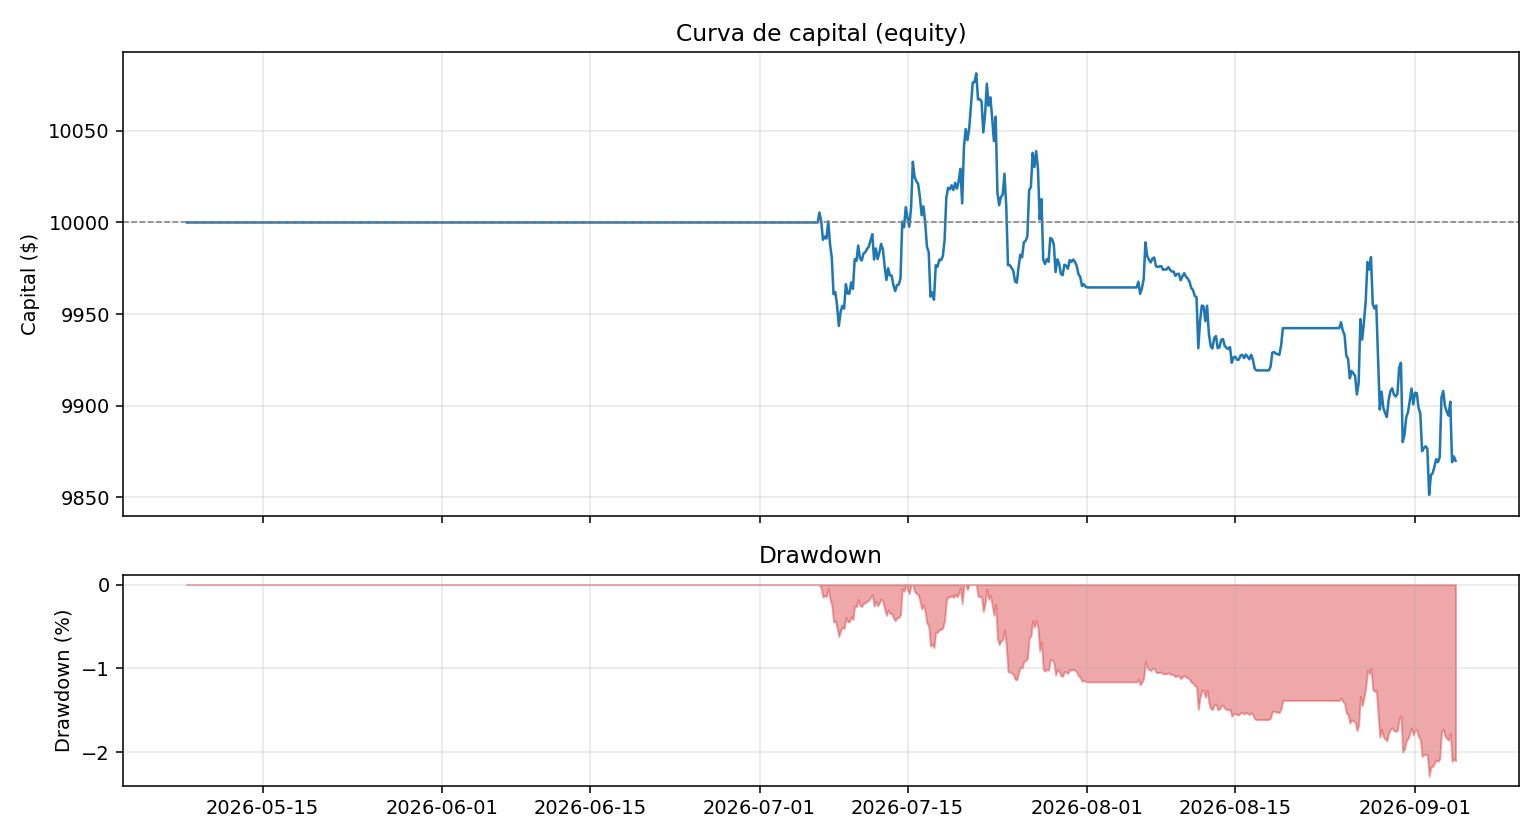

In [ ]:
from IPython.display import Image, display
from modulo_4_backtesting import graficar_equity_drawdown

ruta_grafico = graficar_equity_drawdown(
    resultado_multiactivo.resultado_combinado, main.CONFIG.ruta_grafico
)
display(Image(ruta_grafico))


## 5. (Opcional) Explorar las operaciones individuales
`resultado_multiactivo.resultado_combinado` trae el pool de operaciones de todos los activos (cada una con su campo `activo` para saber de qué ticker viene); `resultado_multiactivo.resultados_por_activo` trae el detalle de cada activo por separado, por si quieres auditar uno en concreto.

In [ ]:
import pandas as pd

df_trades = pd.DataFrame(
    [t.__dict__ for t in resultado_multiactivo.resultado_combinado.trades]
)
df_trades.tail(15)


,fecha_entrada,fecha_salida,direccion,precio_entrada,precio_salida,unidades,motivo_salida,comision_total,pnl_bruto,pnl_neto,capital_antes,capital_despues,activo
45,2026-08-27 00:00:00+00:00,2026-08-30 20:00:00+00:00,1,11.624634,11.056920,22.162216,stop_loss,0.301604,-12.581811,-12.883415,1253.279244,1240.395828,LINK/USDT
46,2026-08-27 16:00:00+00:00,2026-08-30 20:00:00+00:00,1,107.121420,101.797348,2.360758,stop_loss,0.295924,-12.568847,-12.864771,1252.077532,1239.212761,SOL/USDT
47,2026-08-27 16:00:00+00:00,2026-08-28 16:00:00+00:00,1,0.214918,0.201878,950.448364,stop_loss,0.237686,-12.394247,-12.631932,1235.586404,1222.954472,ADA/USDT
48,2026-08-28 20:00:00+00:00,2026-08-29 08:00:00+00:00,1,0.202189,0.199791,1024.926334,senal_contraria,0.247200,-2.458179,-2.705379,1222.954472,1220.249092,ADA/USDT
49,2026-08-31 00:00:00+00:00,2026-09-02 08:00:00+00:00,1,101.730342,97.438070,2.900249,stop_loss,0.346583,-12.448657,-12.795240,1239.212761,1226.417522,SOL/USDT
50,2026-08-31 00:00:00+00:00,2026-08-31 04:00:00+00:00,1,0.081996,0.082124,3795.654265,senal_contraria,0.373766,0.482716,0.108951,1237.259281,1237.368232,DOGE/USDT
51,2026-08-31 00:00:00+00:00,2026-09-02 16:00:00+00:00,1,11.146149,11.100789,30.154776,senal_contraria,0.402511,-1.367802,-1.770313,1240.395828,1238.625515,LINK/USDT
52,2026-09-02 12:00:00+00:00,2026-09-03 08:00:00+00:00,1,2381.666238,2398.630178,0.178026,senal_contraria,0.510610,3.020022,2.509412,1248.274723,1250.784135,ETH/USDT
53,2026-09-02 12:00:00+00:00,2026-09-03 16:00:00+00:00,1,98.069610,105.683949,3.212417,take_profit,0.392725,24.460433,24.067708,1226.417522,1250.485230,SOL/USDT
54,2026-09-03 16:00:00+00:00,2026-09-04 12:00:00+00:00,1,2517.553410,2438.262655,0.158723,stop_loss,0.471961,-12.585267,-13.057228,1250.784135,1237.726907,ETH/USDT


## 6. Diagnóstico: ¿por qué un activo dio 0 (o muy pocas) operaciones?
`diagnosticar_activo()` NO ejecuta ningún backtest: descarga el activo indicado y comprueba, en orden, (1) si el dato crudo tiene calidad razonable (precio con variación normal, no plano/ilíquido), (2) si el histórico real cubierto se acerca al solicitado en `CONFIG.periodo_historico` (así se detectó que XRP/USDT solo tenía ~4 meses reales en Kraken pese a pedir 3 años, y por eso ya no está en la cesta por defecto), y (3) cuántos cruces de EMA sobreviven a cada filtro de régimen por separado — para saber si el problema es el DATO o el FILTRO. La celda 3 ya avisa sola en el log si algún activo de la cesta tiene poca cobertura histórica; usa esta celda para el detalle completo de uno en concreto (edita el ticker de abajo).

In [ ]:
main.diagnosticar_activo(main.CONFIG, 'BTC/USDT')

# Para investigar otro activo, cambia el ticker, p. ej.:
# main.diagnosticar_activo(main.CONFIG, 'LINK/USDT')



DIAGNÓSTICO: BTC/USDT
Velas descargadas: 721
Rango de fechas:   2026-05-07 20:00:00+00:00 -> 2026-09-04 20:00:00+00:00
Close min/max/mean/std: 58400.000000 / 82166.900000 / 68370.704716 / 6986.171263
Valores de Close distintos entre velas consecutivas: 714 de 721 (99.0%)
Histórico solicitado: ~1095 días (3y) | histórico realmente cubierto: ~120 días (11.0%)
AVISO: el histórico real cubre solo el 11.0% de lo solicitado. Lo más probable es que este ticker NO tenga 3y de antigüedad en el exchange configurado (par listado más tarde, o con menos profundidad histórica disponible vía la API pública) — el filtro EMA200/ADX puede estar operando correctamente, pero sobre una ventana real mucho más corta de lo que `config.periodo_historico` sugiere.

Reclamos de EMA20 dentro de estructura alcista (EMA20 > EMA50) (sin ningún filtro de régimen): 16
  Velas con tendencia macro alcista (Close > EMA200): 237 de 721 (32.9%) | eventos que la cumplen: 10
  ADX min/max/mean: 12.29 / 73.68 / 30.49
  Velas